# Data Loading and Cleaning Structure

To ensure a consistent, organized, and reproducible workflow, each NHANES dataset is processed independently before being merged into the final dataset.

Each data-preparation section follows the same structure, allowing every dataset to be fully cleaned and ready for analysis on its own. This approach improves code readability, simplifies debugging, and makes the entire cleaning process easier to understand and maintain.

Each dataset is processed through the following steps:

1. **Load the dataset**:
   Import the original NHANES dataset.

2. **Rename variables**:
   Replace NHANES variable codes with descriptive and meaningful column names.

3. **Select variables**:
   Retain only the variables relevant to this project's objectives.

4. **Replace NHANES missing-value codes with NaN**:
   Convert NHANES-specific missing-value codes (e.g., *Refused*, *Don't know*, etc.) into standard missing values (`NaN`) according to the official codebook.

5. **Dataset-specific corrections**:
   Apply any corrections required for the particular dataset, such as fixing incorrectly imported values or handling special cases identified during data exploration.

6. **Decode variables (where applicable)**:
   Convert encoded values (for example, byte strings representing time) into readable formats.

7. **Replace coded values with descriptive labels**:
   Replace numeric category codes with readable labels to improve interpretability and facilitate exploratory data analysis.

Following this standardized preprocessing workflow ensures that each dataset is clean, consistent, and ready to be integrated into the final analytical dataset.


In [12]:
from pathlib import Path
import pandas as pd

# Locate the data folder from the project root or the notebooks folder
if Path("data").is_dir():
    DATA_DIR = Path("data")
elif Path("../data").is_dir():
    DATA_DIR = Path("../data")
else:
    raise FileNotFoundError(
        "The data folder could not be found. "
        "Run the notebook from the project root or the notebooks folder."
    )

print("Current working directory:", Path.cwd())
print("Data directory:", DATA_DIR.resolve())
print("Data folder found:", DATA_DIR.is_dir())


Current working directory: c:\Users\aleja\Downloads\proyecto-nhanes\notebooks
Data directory: C:\Users\aleja\Downloads\proyecto-nhanes\data
Data folder found: True


In [13]:
# 1 LOAD AND CLEAN DEMO_J 
import pandas as pd
import numpy as np

demo = pd.read_sas(DATA_DIR / "DEMO_J.xpt")

# ===========================
# Rename variables
# ===========================

demo=demo.rename(columns={'RIAGENDR':'Gender',
                                'RIDAGEYR':'Age',
                                'RIDRETH3':'Race',
                                'DMDEDUC2':'Education',
                                'DMDMARTL':'Marital_Status',
                                'INDFMPIR':'Poverty_Index'}) #Annual family income

# Select variables
df_demo=demo[['SEQN','Gender','Age','Race','Education','Marital_Status','Poverty_Index']].copy()


# ===========================
# Replace NHANES missing value codes with NaN
# ===========================

categorical_columns = [
    "Education",
    "Marital_Status"]

df_demo[categorical_columns] = df_demo[categorical_columns].replace({
    7: np.nan,
    9: np.nan,
    77: np.nan,
    99: np.nan
})

# ==========================================
# Correct anomalous value imported by read_sas()
# ==========================================

# read_sas() occasionally imports SAS value 0 as 5.397605346934028e-79

df_demo["Age"] = (
    df_demo["Age"]
    .replace(5.397605346934028e-79, 0)
)

df_demo["Poverty_Index"] = (
    df_demo["Poverty_Index"]
    .replace(5.397605346934028e-79, 0)
)

# ===========================
# Replace coded values with descriptive labels
# ===========================

#Gender:
df_demo['Gender']=df_demo['Gender'].replace({1:'Male',2:'Female'})

#RACE:
df_demo["Race"] = df_demo["Race"].replace({
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    6: "Non-Hispanic Asian",
    7: "Other / Multi-Racial"
})

# Education
df_demo["Education"] = df_demo["Education"].replace({
    1: "Less than 9th grade",
    2: "9-11th grade",
    3: "High school/GED",
    4: "Some college/AA degree",
    5: "College graduate or above"
})

# Marital status
df_demo["Marital_Status"] = df_demo["Marital_Status"].replace({
    1: "Married",
    2: "Widowed",
    3: "Divorced",
    4: "Separated",
    5: "Never married",
    6: "Living with partner"
})


df_demo.head()


,SEQN,Gender,Age,Race,Education,Marital_Status,Poverty_Index
0,93703.0,Female,2.0,Non-Hispanic Asian,NaN,NaN,5.00
1,93704.0,Male,2.0,Non-Hispanic White,NaN,NaN,5.00
2,93705.0,Female,66.0,Non-Hispanic Black,9-11th grade,Divorced,0.82
3,93706.0,Male,18.0,Non-Hispanic Asian,NaN,NaN,NaN
4,93707.0,Male,13.0,Other / Multi-Racial,NaN,NaN,1.88


In [14]:
# 2 LOAD AND CLEAN SLQ_J (sleep disorders)

sleep=pd.read_sas( DATA_DIR / 'SLQ_J.XPT')

sleep = sleep.rename(columns={
    'SLQ300': 'Bedtime_Workdays',
    'SLQ310': 'Wakeup_Workdays',
    'SLD012': 'Sleep_Hours_Workdays',

    'SLQ320': 'Bedtime_Weekend',
    'SLQ330': 'Wakeup_Weekend',
    'SLD013': 'Sleep_Hours_Weekend',

    'SLQ030': 'Snoring_Frequency',
    'SLQ040': 'Breathing_Interruptions_Frequency',
    'SLQ050': 'Reported_Sleep_Trouble_To_Doctor',
    'SLQ120': 'Daytime_Sleepiness_Frequency'
})


df_sleep = sleep[[
    'SEQN',

    'Bedtime_Workdays',
    'Wakeup_Workdays',
    'Sleep_Hours_Workdays',

    'Bedtime_Weekend',
    'Wakeup_Weekend',
    'Sleep_Hours_Weekend',

    'Snoring_Frequency',
    'Breathing_Interruptions_Frequency',
    'Reported_Sleep_Trouble_To_Doctor',
    'Daytime_Sleepiness_Frequency'
]].copy()

# ===========================
# Replace NHANES missing value codes with NaN
# ===========================

categorical_columns = [
    "Snoring_Frequency",
    "Breathing_Interruptions_Frequency",
    "Reported_Sleep_Trouble_To_Doctor",
    "Daytime_Sleepiness_Frequency"
]

df_sleep[categorical_columns] = df_sleep[categorical_columns].replace({
    7: np.nan,
    9: np.nan
})

# ===========================
# Decode time variables
# ===========================

time_columns = [
    "Bedtime_Workdays",
    "Wakeup_Workdays",
    "Bedtime_Weekend",
    "Wakeup_Weekend"]

for col in time_columns: #We convert the byte object type of the time columns
    df_sleep[col] = df_sleep[col].str.decode("utf-8")
    
# ===========================
# Correct incorrectly imported SAS value
# ===========================

# read_sas() occasionally imports some SAS zero values as 5.397605346934028e-79
for col in [
    "Snoring_Frequency",
    "Breathing_Interruptions_Frequency",
    "Daytime_Sleepiness_Frequency"
]:
    df_sleep[col] = df_sleep[col].replace(5.397605346934028e-79, 0)    
    

    
# ===========================
# Replace coded values with descriptive labels
# ===========================

frequency_labels_sleep = {
    0: "Never",
    1: "Rarely (1-2 nights/week)",
    2: "Occasionally (3-4 nights/week)",
    3: "Frequently (5+ nights/week)"
}

for col in [
    "Snoring_Frequency",
    "Breathing_Interruptions_Frequency"
]:
    df_sleep[col] = df_sleep[col].replace(frequency_labels_sleep)

daytime_sleepiness_labels = {
    0: "Never",
    1: "Rarely (1 time/month)",
    2: "Sometimes (2-4 times/month)",
    3: "Often (5-15 times/month)",
    4: "Almost always (16-30 times/month)"
}

df_sleep['Daytime_Sleepiness_Frequency'] = df_sleep['Daytime_Sleepiness_Frequency'].replace(daytime_sleepiness_labels)

df_sleep["Reported_Sleep_Trouble_To_Doctor"] = (
    df_sleep["Reported_Sleep_Trouble_To_Doctor"]
    .replace({
        1: "Yes",
        2: "No"
    })
)


df_sleep.head()



,SEQN,Bedtime_Workdays,Wakeup_Workdays,Sleep_Hours_Workdays,Bedtime_Weekend,Wakeup_Weekend,Sleep_Hours_Weekend,Snoring_Frequency,Breathing_Interruptions_Frequency,Reported_Sleep_Trouble_To_Doctor,Daytime_Sleepiness_Frequency
0,93705.0,23:00,07:00,8.0,23:00,07:00,8.0,Occasionally (3-4 nights/week),Never,No,Never
1,93706.0,23:30,10:00,10.5,00:30,12:00,11.5,Rarely (1-2 nights/week),Never,No,Rarely (1 time/month)
2,93708.0,22:30,06:30,8.0,22:30,06:30,8.0,NaN,Never,No,Sometimes (2-4 times/month)
3,93709.0,22:30,05:30,7.0,22:30,05:00,6.5,Rarely (1-2 nights/week),Never,No,Rarely (1 time/month)
4,93711.0,22:00,05:00,7.0,23:00,08:00,9.0,Occasionally (3-4 nights/week),Rarely (1-2 nights/week),Yes,Often (5-15 times/month)


In [15]:
# 3 CLEAN BMX_J (BODY MEASURES)

# ===========================
# Load dataset
# ===========================

body=pd.read_sas(DATA_DIR / 'BMX_J.XPT')

# ===========================
# Rename variables
# ===========================

body = body.rename(columns={
    "BMXWT": "Weight",
    "BMXHT": "Height",
    "BMXBMI": "BMI",
    "BMXWAIST": "Waist_Circumference",
    "BMXHIP": "Hip_Circumference"
})

# ===========================
# Select variables
# ===========================

df_body = body[[
    'SEQN',
    "Weight",
    "Height",
    "BMI",
    "Waist_Circumference",
    "Hip_Circumference"
]].copy()

# ===========================
# Replace NHANES missing value codes with NaN
# ===========================

# No replacement needed.
# Missing values are already imported as NaN.


df_body.head()


,SEQN,Weight,Height,BMI,Waist_Circumference,Hip_Circumference
0,93703.0,13.7,88.6,17.5,48.2,NaN
1,93704.0,13.9,94.2,15.7,50.0,NaN
2,93705.0,79.5,158.3,31.7,101.8,110.0
3,93706.0,66.3,175.7,21.5,79.3,94.4
4,93707.0,45.4,158.4,18.1,64.1,83.0


In [16]:
# 5 CLEAN Glycohemoglobin (GHB_J)

# ===========================
# Load dataset
# ===========================

df_ghb=pd.read_sas(DATA_DIR / 'GHB_J.XPT')


# ===========================
# Rename variables
# ===========================
df_ghb = df_ghb.rename(columns={
    'LBXGH': 'HbA1c' # HbA1c reflects average blood glucose levels over the previous 2–3 months. 
                     
})

# ===========================
# Select variables
# ===========================
df_ghb = df_ghb[['SEQN', 'HbA1c']].copy()

# ===========================
# Replace NHANES missing value codes with NaN
# ===========================

# No replacement needed.
# Missing values are already imported as NaN.

df_ghb
    

,SEQN,HbA1c
0,93705.0,6.2
1,93706.0,5.2
2,93707.0,5.6
3,93708.0,6.2
4,93709.0,6.3
...,...,...
6396,102952.0,7.4
6397,102953.0,5.9
6398,102954.0,5.2
6399,102955.0,5.5


In [17]:
# 6 CLEAN Blood Pressure (BPX_J)

# ===========================
# Load dataset
# ===========================
pressure=pd.read_sas(DATA_DIR / 'BPX_J.XPT')

# Replace the incorrectly imported value from the source file 
# read_sas() occasionally imports some SAS zero values as 5.397605346934028e-79
for col in ["BPXDI1", "BPXDI2", "BPXDI3", "BPXDI4"]:
    pressure[col] = pressure[col].replace(5.397605346934028e-79, 0)

# ===========================
# Rename variables
# ===========================
pressure = pressure.rename(columns={
    'BPXSY1': 'Systolic_BP_1',
    'BPXSY2': 'Systolic_BP_2',
    'BPXSY3': 'Systolic_BP_3',
    'BPXSY4': 'Systolic_BP_4',

    'BPXDI1': 'Diastolic_BP_1',
    'BPXDI2': 'Diastolic_BP_2',
    'BPXDI3': 'Diastolic_BP_3',
    'BPXDI4': 'Diastolic_BP_4'
})

# ===========================
# Select variables
# ===========================
df_pressure = pressure[[
    'SEQN',
    'Systolic_BP_1',
    'Systolic_BP_2',
    'Systolic_BP_3',
    'Systolic_BP_4',
    'Diastolic_BP_1',
    'Diastolic_BP_2',
    'Diastolic_BP_3',
    'Diastolic_BP_4'
]].copy()

# ===========================
# Replace NHANES missing value codes with NaN
# ===========================

# No replacement needed.
# Missing values are already imported as NaN.


# ===========================
# Calculate mean blood pressure
# ===========================

# Calculate the mean systolic blood pressure from the four available measurements.
df_pressure["Systolic_BP"] = df_pressure[
    ["Systolic_BP_1","Systolic_BP_2","Systolic_BP_3","Systolic_BP_4"]
].mean(axis=1)

# Calculate the mean diastolic blood pressure from the four available measurements.
df_pressure["Diastolic_BP"] = df_pressure[
    ["Diastolic_BP_1","Diastolic_BP_2","Diastolic_BP_3","Diastolic_BP_4"]
].mean(axis=1)


# ===========================
# Keep final variables
# ===========================

# Keep only the participant identifier and the mean systolic and diastolic
# blood pressure values for the final analytical dataset.
df_pressure=df_pressure[['SEQN','Systolic_BP','Diastolic_BP']].copy()


df_pressure.head()

,SEQN,Systolic_BP,Diastolic_BP
0,93703.0,NaN,NaN
1,93704.0,NaN,NaN
2,93705.0,200.000000,68.000000
3,93706.0,111.333333,73.333333
4,93707.0,128.000000,47.333333


In [18]:
# 7 CLEAN Cholesterol - High - Density Lipoprotein (HDL) (HDL_J)

# ===========================
# Load dataset
# ===========================
df_hdl=pd.read_sas( DATA_DIR / 'HDL_J.XPT')


# ===========================
# Rename variables
# ===========================
df_hdl = df_hdl.rename(columns={
    'LBDHDD': 'HDL' #HDL significa High-Density Lipoprotein, conocido como colesterol HDL o "colesterol bueno".
})

# ===========================
# Select variables
# ===========================
df_hdl = df_hdl[['SEQN', 'HDL']].copy()

df_hdl.head()

,SEQN,HDL
0,93705.0,60.0
1,93706.0,47.0
2,93707.0,68.0
3,93708.0,88.0
4,93709.0,65.0


In [19]:
# 8 CLEAN Physical Activity (PAQ_J)
import pandas as pd

# ===========================
# Load dataset
# ===========================

df_paq=pd.read_sas(DATA_DIR / 'PAQ_J.XPT')

df_paq = df_paq.rename(columns={
    # Occupational physical activity 
    # Physical Activity at Work
    'PAQ605': 'Vigorous_Work',
    'PAQ610': 'Vigorous_Work_Days',
    'PAD615': 'Vigorous_Work_Minutes',

    'PAQ620': 'Moderate_Work',
    'PAQ625': 'Moderate_Work_Days',
    'PAD630': 'Moderate_Work_Minutes',

    # Transporte activo
    # Active Transport
    'PAQ635': 'Active_Transport',
    'PAQ640': 'Active_Transport_Days',
    'PAD645': 'Active_Transport_Minutes',

    # Recreational physical activity
    # Recreational Physical Activity
    'PAQ650': 'Vigorous_Recreation',
    'PAQ655': 'Vigorous_Recreation_Days',
    'PAD660': 'Vigorous_Recreation_Minutes',

    'PAQ665': 'Moderate_Recreation',
    'PAQ670': 'Moderate_Recreation_Days',
    'PAD675': 'Moderate_Recreation_Minutes',

    #Sedentarismo
    #Sedentary Lifestyle
    'PAD680': 'Sedentary_Minutes_Per_Day'
})

# ===========================
# Select variables
# ===========================

df_paq = df_paq[[
    "SEQN",

    "Vigorous_Work",
    "Vigorous_Work_Days",
    "Vigorous_Work_Minutes",

    "Moderate_Work",
    "Moderate_Work_Days",
    "Moderate_Work_Minutes",

    "Active_Transport",
    "Active_Transport_Days",
    "Active_Transport_Minutes",

    "Vigorous_Recreation",
    "Vigorous_Recreation_Days",
    "Vigorous_Recreation_Minutes",

    "Moderate_Recreation",
    "Moderate_Recreation_Days",
    "Moderate_Recreation_Minutes",

    "Sedentary_Minutes_Per_Day"
]].copy()


# ===========================
# Replace NHANES missing value codes with NaN
# ===========================

categorical_columns = [
    "Vigorous_Work",
    "Moderate_Work",
    "Active_Transport",
    "Vigorous_Recreation",
    "Moderate_Recreation"
]

days_columns = [
    "Vigorous_Work_Days",
    "Moderate_Work_Days",
    "Active_Transport_Days",
    "Vigorous_Recreation_Days",
    "Moderate_Recreation_Days"
]

minutes_columns = [
    "Vigorous_Work_Minutes",
    "Moderate_Work_Minutes",
    "Active_Transport_Minutes",
    "Vigorous_Recreation_Minutes",
    "Moderate_Recreation_Minutes",
    "Sedentary_Minutes_Per_Day"
]

df_paq[categorical_columns] = df_paq[categorical_columns].replace(9, np.nan)
df_paq[days_columns] = df_paq[days_columns].replace(99, np.nan)
df_paq[minutes_columns] = df_paq[minutes_columns].replace(9999, np.nan)

df_paq["Sedentary_Minutes_Per_Day"] = (df_paq["Sedentary_Minutes_Per_Day"].replace(5.397605346934028e-79, 0))

# ===========================
# Replace coded values
# ===========================

activity_labels = {
    1: "Yes",
    2: "No"
}

df_paq[categorical_columns] = (
    df_paq[categorical_columns]
    .replace(activity_labels)
)

df_paq.head()


,SEQN,Vigorous_Work,Vigorous_Work_Days,Vigorous_Work_Minutes,Moderate_Work,Moderate_Work_Days,Moderate_Work_Minutes,Active_Transport,Active_Transport_Days,Active_Transport_Minutes,Vigorous_Recreation,Vigorous_Recreation_Days,Vigorous_Recreation_Minutes,Moderate_Recreation,Moderate_Recreation_Days,Moderate_Recreation_Minutes,Sedentary_Minutes_Per_Day
0,93705.0,No,NaN,NaN,No,NaN,NaN,No,NaN,NaN,No,NaN,NaN,Yes,2.0,60.0,300.0
1,93706.0,No,NaN,NaN,No,NaN,NaN,Yes,5.0,45.0,No,NaN,NaN,Yes,2.0,30.0,240.0
2,93708.0,No,NaN,NaN,No,NaN,NaN,No,NaN,NaN,No,NaN,NaN,Yes,5.0,30.0,120.0
3,93709.0,No,NaN,NaN,Yes,2.0,180.0,No,NaN,NaN,No,NaN,NaN,No,NaN,NaN,600.0
4,93711.0,No,NaN,NaN,No,NaN,NaN,Yes,5.0,60.0,Yes,4.0,60.0,Yes,2.0,30.0,420.0


In [20]:
# 9 CLEAN Smoking - Cigarette Use (SMQ_J)
import pandas as pd
import numpy as np

# ===========================
# Load dataset
# ===========================

smq=pd.read_sas(DATA_DIR / 'SMQ_J.XPT')


smq = smq.rename(columns={
    'SMQ020': 'Ever_Smoked_100_Cigarettes',
    'SMD030': 'Smoking_Start_Age',
    'SMQ040': 'Current_Smoking_Status',
    'SMQ050Q': 'Time_Since_Quitting',
    'SMQ050U': 'Time_Since_Quitting_Unit',
    'SMD057': 'Cigarettes_Per_Day_When_Quit'
})

df_smoking = smq[[
    'SEQN',
    'Ever_Smoked_100_Cigarettes',
    'Smoking_Start_Age',
    'Current_Smoking_Status',
    'Time_Since_Quitting',
    'Time_Since_Quitting_Unit'
]].copy()

# ===========================
# Replace NHANES missing value codes with NaN
# ===========================
categorical_columns = [
    "Ever_Smoked_100_Cigarettes",
    "Current_Smoking_Status",
    "Time_Since_Quitting_Unit"
]

df_smoking[categorical_columns] = df_smoking[categorical_columns].replace({
    7: np.nan,
    9: np.nan
})

# read_sas() occasionally imports some SAS zero values as 5.397605346934028e-79
df_smoking["Smoking_Start_Age"] = (
    df_smoking["Smoking_Start_Age"]
    .replace(5.397605346934028e-79, 0)
)

numeric_columns = [
    "Smoking_Start_Age",
    "Time_Since_Quitting"
]

df_smoking[numeric_columns] = df_smoking[numeric_columns].replace({
    777: np.nan,
    999: np.nan
})


# ===========================
# Replace coded values with descriptive labels
# ===========================

# Ever smoked at least 100 cigarettes
df_smoking["Ever_Smoked_100_Cigarettes"] = (
    df_smoking["Ever_Smoked_100_Cigarettes"]
    .replace({
        1: "Yes",
        2: "No"
    })
)

# Current smoking status
df_smoking["Current_Smoking_Status"] = (
    df_smoking["Current_Smoking_Status"]
    .replace({
        1: "Every day",
        2: "Some days",
        3: "Not at all"
    })
)

# Time since quitting unit
df_smoking["Time_Since_Quitting_Unit"] = (
    df_smoking["Time_Since_Quitting_Unit"]
    .replace({
        1: "Days",
        2: "Weeks",
        3: "Months",
        4: "Years"
    })
)

df_smoking.head()

,SEQN,Ever_Smoked_100_Cigarettes,Smoking_Start_Age,Current_Smoking_Status,Time_Since_Quitting,Time_Since_Quitting_Unit
0,93705.0,Yes,16.0,Not at all,30.0,Years
1,93706.0,No,NaN,NaN,NaN,NaN
2,93707.0,NaN,NaN,NaN,NaN,NaN
3,93708.0,No,NaN,NaN,NaN,NaN
4,93709.0,Yes,15.0,Every day,NaN,NaN


In [21]:
# 10 LOAD AND CLEAN Alcohol Use (ALQ_J)
import pandas as pd
import numpy as np

df_alcohol=pd.read_sas(DATA_DIR / 'ALQ_J.XPT')

# ===========================
# Rename variables
# ===========================

df_alcohol = df_alcohol.rename(columns={
    "ALQ111": "Ever_Had_Alcohol",
    "ALQ121": "Alcohol_Frequency_Last_12_Months",
    "ALQ130": "Average_Drinks_Per_Day",
    "ALQ142": "Heavy_Drinking_Frequency_Last_12_Months",
    "ALQ270": "Binge_Drinking_2h_Frequency_Last_12_Months",
    "ALQ280": "Days_With_8_Or_More_Drinks_Last_12_Months",
    "ALQ290": "Days_With_12_Or_More_Drinks_Last_12_Months",
    "ALQ151": "Ever_Been_Heavy_Drinker",
    "ALQ170": "Binge_Drinking_Last_30_Days"
})

# ===========================
# Select variables
# ===========================
df_alcohol = df_alcohol[[
    "SEQN",
    "Ever_Had_Alcohol",
    "Alcohol_Frequency_Last_12_Months",
    "Average_Drinks_Per_Day", # Value 15 represents "15 or more drinks"
    "Binge_Drinking_Last_30_Days"
]].copy()

# ===========================
# Replace NHANES missing value codes with NaN
# ===========================

categorical_columns = [
    "Ever_Had_Alcohol",
    "Alcohol_Frequency_Last_12_Months"
]

df_alcohol[categorical_columns] = df_alcohol[categorical_columns].replace({
    7: np.nan,
    9: np.nan,
    77: np.nan,
    99: np.nan
})

numeric_columns = [
    "Average_Drinks_Per_Day",
    "Binge_Drinking_Last_30_Days"
]

df_alcohol[numeric_columns] = df_alcohol[numeric_columns].replace({
    777: np.nan,
    999: np.nan
})

# ===========================
# Correct incorrectly imported SAS values
# ===========================

# read_sas() imports some 0 values as 5.397605346934028e-79

columns_with_zero_issue = [
    "Alcohol_Frequency_Last_12_Months",
    "Binge_Drinking_Last_30_Days"
]

for col in columns_with_zero_issue:
    df_alcohol[col] = df_alcohol[col].replace(
        5.397605346934028e-79,
        0
    )

# ===========================
# Replace coded values with descriptive labels
# ===========================

df_alcohol["Ever_Had_Alcohol"] = (
    df_alcohol["Ever_Had_Alcohol"]
    .replace({
        1: "Yes",
        2: "No"
    })
)

alcohol_frequency_labels = {
    0: "Never in the last 12 months",
    1: "Every day",
    2: "Nearly every day",
    3: "3-4 times per week",
    4: "Twice a week",
    5: "Once a week",
    6: "2-3 times per month",
    8: "Once a month",
    10: "3-11 times in the last year"
}

df_alcohol["Alcohol_Frequency_Last_12_Months"] = (
    df_alcohol["Alcohol_Frequency_Last_12_Months"]
    .replace(alcohol_frequency_labels)
)

df_alcohol.head()



,SEQN,Ever_Had_Alcohol,Alcohol_Frequency_Last_12_Months,Average_Drinks_Per_Day,Binge_Drinking_Last_30_Days
0,93705.0,Yes,NaN,1.0,5.0
1,93706.0,No,NaN,NaN,NaN
2,93708.0,No,NaN,NaN,NaN
3,93709.0,NaN,NaN,NaN,NaN
4,93711.0,Yes,Once a week,1.0,0.0


# Merging the NHANES Datasets

The individual NHANES datasets are merged into a single analytical dataset using the participant identifier (`SEQN`).

- `df_demo` is used as the base dataset because it contains demographic information and all participants included in the study.
- A **left join** is applied sequentially to each of the remaining datasets to retain all participants from the demographic dataset, even when information is missing from some of the other files.
- After each merge, the dimensions of the resulting DataFrame are displayed to verify that the integration process was completed correctly.


In [22]:
# Dictionary containing all processed NHANES datasets
dfs = {
    'demo': df_demo,
    'sleep': df_sleep,
    'smoking': df_smoking,
    'alcohol': df_alcohol,
    'body': df_body,
    'physical_activity': df_paq,
    'Glycohemoglobin': df_ghb,
    'Blood Pressure': df_pressure,
    'Cholesterol': df_hdl
}

# Create a copy of the demographic dataset to use as the base dataframe
df_final = dfs['demo'].copy()

# Sequentially merge each dataset using the participant identifier (SEQN)
# A left join is used to retain all participants from the demographic dataset
for dataset_name, df_current in dfs.items():

    if dataset_name != 'demo':

        df_final = df_final.merge(
            df_current,
            on='SEQN',
            how='left'
        )

        # Display the dataframe shape after each merge
        print(f'{dataset_name}: {df_final.shape}')

sleep: (9254, 17)
smoking: (9254, 22)
alcohol: (9254, 26)
body: (9254, 31)
physical_activity: (9254, 47)
Glycohemoglobin: (9254, 48)
Blood Pressure: (9254, 50)
Cholesterol: (9254, 51)


## Checking for Duplicate Participants

Before merging the datasets, it is important to verify that the participant identifier (`SEQN`) is unique within each DataFrame.

Because `SEQN` is the key used to merge all NHANES files, duplicate identifiers could produce incorrect merges by generating duplicate rows or many-to-many relationships. This validation ensures that each participant appears only once in each dataset before integration.


In [23]:
# Check whether the participant identifier (SEQN) is unique in each dataset
for dataset_name, current_df in dfs.items():

    # Count duplicated participant IDs
    duplicated_ids = current_df['SEQN'].duplicated().sum()

    # Display the number of duplicates found
    print(dataset_name, duplicated_ids)

demo 0
sleep 0
smoking 0
alcohol 0
body 0
physical_activity 0
Glycohemoglobin 0
Blood Pressure 0
Cholesterol 0


## Validation of the Resulting Dataset

The merged DataFrame is reviewed to verify its integrity before proceeding with data cleaning.

The following information is displayed:

- Number of rows and columns.
- Number of duplicate participant identifiers (`SEQN`).
- Percentage of missing values for each variable.


In [24]:
print("=" * 40)
print("DATAFRAME")
print("=" * 40)

# Display the dimensions of the merged dataset
print(f"Rows: {df_final.shape[0]}")
print(f"Columns: {df_final.shape[1]}")

# Verify that each participant appears only once
print(f"\nDuplicated SEQN values: {df_final['SEQN'].duplicated().sum()}")


DATAFRAME
Rows: 9254
Columns: 51

Duplicated SEQN values: 0


## Assessment of Missing Values

A missing-values summary table is generated to assess data completeness before cleaning.

For each variable, the following information is displayed:

- Number of missing values.
- Percentage of missing values.
- Data type.

Only variables containing missing values are shown, ordered from highest to lowest percentage of missing data.


In [25]:
# Summarize missing values for each variable
na = pd.DataFrame({
    "NaN": df_final.isna().sum(),
    "%": (df_final.isna().mean() * 100).round(2),
    "Data Type": df_final.dtypes
})

# Keep only variables with missing values and sort them
na = (
    na[na["NaN"] > 0]
      .sort_values("%", ascending=False)
)

na

,NaN,%,Data Type
Time_Since_Quitting_Unit,7999,86.44,object
Time_Since_Quitting,7916,85.54,float64
Vigorous_Work_Minutes,7879,85.14,float64
Vigorous_Work_Days,7866,85.00,float64
Active_Transport_Minutes,7828,84.59,float64
Vigorous_Recreation_Minutes,7824,84.55,float64
Vigorous_Recreation_Days,7821,84.51,float64
Active_Transport_Days,7819,84.49,float64
Moderate_Recreation_Minutes,6954,75.15,float64
Moderate_Recreation_Days,6949,75.09,float64


## Creation of the Analysis-Specific Dataset

NHANES includes participants of all ages; however, this study focuses exclusively on adults aged 20 years or older.

Therefore, an analytical dataset (`df_analysis`) was created by selecting adult participants from the final dataset.

This restriction was applied because several variables examined in this project—including BMI classification, alcohol consumption, smoking status, blood pressure, and biochemical markers—are defined differently or are not systematically available for children and adolescents.

Restricting the analysis to adults improves methodological consistency and ensures that all variables are directly comparable across participants.


In [26]:
# Create the analytical dataset
df_analysis = df_final.copy()

print(f"Participants before filtering: {len(df_analysis)}")

# Keep only participants aged 20 years or older
df_analysis = df_analysis[df_analysis["Age"] >= 20].copy()

print(f"Participants after filtering: {len(df_analysis)}")

# Reset the index after filtering
df_analysis.reset_index(drop=True, inplace=True)

Participants before filtering: 9254
Participants after filtering: 5569


## Smoking Frequency or Habit

The original NHANES smoking questionnaire contains several variables describing smoking history (for example, lifetime smoking and current smoking habits).

To simplify the analysis, these variables were combined into a single categorical variable (`Smoking_Status`).

The resulting categories are:

- **Never smoker**
- **Former smoker**
- **Current smoker**

Participants for whom there was insufficient information to determine smoking status were retained as missing data (`NaN`).


In [27]:
# Create an empty column to store the derived smoking status
df_analysis["Smoking_Status"] = pd.Series(dtype="object")

# Participants who have never smoked at least 100 cigarettes
df_analysis.loc[
    df_analysis["Ever_Smoked_100_Cigarettes"] == "No",
    "Smoking_Status"
] = "Never smoker"

# Participants who smoked in the past but do not currently smoke
df_analysis.loc[
    df_analysis["Current_Smoking_Status"] == "Not at all",
    "Smoking_Status"
] = "Former smoker"

# Participants who currently smoke
df_analysis.loc[
    df_analysis["Current_Smoking_Status"].isin(["Every day", "Some days"]),
    "Smoking_Status"
] = "Current smoker"


# Remove the original smoking variables after creating the summary variable
df_analysis.drop(
    columns=[
        "Ever_Smoked_100_Cigarettes",
        "Current_Smoking_Status",
        "Smoking_Start_Age",
        "Time_Since_Quitting",
        "Time_Since_Quitting_Unit"
    ],
    inplace=True,
    errors="ignore"
)


### Validation of the Derived Variable

The distribution of the new `Smoking_Status` categories is reviewed to verify that recoding was performed correctly and to identify the proportion of missing values.


In [28]:
# Frequency distribution
df_analysis["Smoking_Status"].value_counts(dropna=False)

# Percentage distribution
round(
    df_analysis["Smoking_Status"]
        .value_counts(dropna=False, normalize=True) * 100,
    2
)

Smoking_Status
Never smoker      58.07
Former smoker     23.86
Current smoker    18.06
Name: proportion, dtype: float64

## Derivation of the `Alcohol_Consumption` Variable

The original NHANES alcohol-consumption questionnaire includes several variables related to drinking patterns, such as lifetime alcohol consumption and drinking frequency during the previous 12 months.

For this study, these variables were combined into a single ordinal variable (`Alcohol_Consumption`) representing each participant's usual alcohol-consumption pattern.

The classification preserves the original NHANES response categories and provides a simpler variable for statistical analysis and data visualization.

| Alcohol_Consumption | NHANES Category |
|---------------------|------------------|
| Never | Never consumed alcohol |
| Former | Did not consume alcohol during the previous 12 months |
| Rare | 3–11 times during the previous year |
| Occasional | Once a month / 2–3 times a month |
| Regular | Once a week / Twice a week |
| Frequent | 3–4 times a week |
| Daily | Almost every day / Every day |


In [29]:
# =====================================================
# Alcohol Consumption Category
# =====================================================

df_analysis["Alcohol_Consumption"] = pd.Series(dtype="object")

# Participants who have never consumed alcohol
df_analysis.loc[
    df_analysis["Ever_Had_Alcohol"] == "No",
    "Alcohol_Consumption"
] = "Never"

# Former drinkers (consumed alcohol in the past but not during the last year)
df_analysis.loc[
    (df_analysis["Ever_Had_Alcohol"] == "Yes") &
    (df_analysis["Alcohol_Frequency_Last_12_Months"] == "Never in the last 12 months"),
    "Alcohol_Consumption"
] = "Former"

# Rare drinkers
df_analysis.loc[
    df_analysis["Alcohol_Frequency_Last_12_Months"] == "3-11 times in the last year",
    "Alcohol_Consumption"
] = "Rare"

# Monthly drinkers

df_analysis.loc[
    df_analysis["Alcohol_Frequency_Last_12_Months"].isin([
        "Once a month",
        "2-3 times per month"
    ]),
    "Alcohol_Consumption"
] = "Occasional"

# Weekly drinkers
df_analysis.loc[
    df_analysis["Alcohol_Frequency_Last_12_Months"].isin([
        "Once a week",
        "Twice a week"
    ]),
    "Alcohol_Consumption"
] = "Regular"

# Frequent weekly drinkers
df_analysis.loc[
    df_analysis["Alcohol_Frequency_Last_12_Months"] == "3-4 times per week",
    "Alcohol_Consumption"
] = "Frequent"

# Daily drinkers
df_analysis.loc[
    df_analysis["Alcohol_Frequency_Last_12_Months"].isin([
        "Nearly every day",
        "Every day"
    ]),
    "Alcohol_Consumption"
] = "Daily"

# ==========================================================
# Create Alcohol_Consumption categorical variable
# ==========================================================

# Define the natural order of the categories.
# This ordering will be preserved in tables, plots and statistical analyses.
order = [
    "Never",
    "Former",
    "Rare",
    "Occasional",
    "Regular",
    "Frequent",
    "Daily"
]

df_analysis["Alcohol_Consumption"] = pd.Categorical(
    df_analysis["Alcohol_Consumption"],
    categories=order,
    ordered=True
)


df_alcohol.head()

,SEQN,Ever_Had_Alcohol,Alcohol_Frequency_Last_12_Months,Average_Drinks_Per_Day,Binge_Drinking_Last_30_Days
0,93705.0,Yes,NaN,1.0,5.0
1,93706.0,No,NaN,NaN,NaN
2,93708.0,No,NaN,NaN,NaN
3,93709.0,NaN,NaN,NaN,NaN
4,93711.0,Yes,Once a week,1.0,0.0


## Validation of the `Alcohol_Consumption` Variable

### Objective

Verify that the derived variable correctly classifies participants according to their alcohol-consumption pattern.

### Validation

- Participants who answered **"No"** to `Ever_Had_Alcohol` were classified as **Never**.
- Participants who answered **"Yes"** were classified according to their alcohol-consumption frequency during the previous 12 months.
- Participants with insufficient or missing information in the original NHANES questionnaire retained missing values (`NaN`).

### Result

The contingency table confirmed that all participants were classified correctly and that no inconsistencies were detected in the recoding process.


In [30]:
pd.crosstab(
    df_analysis["Ever_Had_Alcohol"],
    df_analysis["Alcohol_Consumption"],
    dropna=False
)

Alcohol_Consumption,Never,Former,Rare,Occasional,Regular,Frequent,Daily
Ever_Had_Alcohol,,,,,,,
NaN,0,0,0,0,0,0,0
No,509,0,0,0,0,0,0
Yes,0,1034,496,850,648,270,296


## Derivation of the `BMI_Category` Variable

Body Mass Index (BMI) was transformed into an ordinal categorical variable following the classification established by the World Health Organization (WHO).

This transformation facilitates interpretation of participants' nutritional status and enables clinically meaningful comparisons among BMI groups during exploratory and statistical analyses.


In [31]:
# ==========================================================
# Create BMI_Category according to WHO classification
# ==========================================================

# Initialize the new variable
df_analysis["BMI_Category"] = pd.Series(dtype="object")

# Underweight
df_analysis.loc[
    df_analysis["BMI"] < 18.5,
    "BMI_Category"
] = "Underweight"

# Normal weight
df_analysis.loc[
    (df_analysis["BMI"] >= 18.5) &
    (df_analysis["BMI"] < 25),
    "BMI_Category"
] = "Normal"

# Overweight
df_analysis.loc[
    (df_analysis["BMI"] >= 25) &
    (df_analysis["BMI"] < 30),
    "BMI_Category"
] = "Overweight"

# Obesity
df_analysis.loc[
    df_analysis["BMI"] >= 30,
    "BMI_Category"
] = "Obese"


# Define the natural order of BMI categories

bmi_order = [
    "Underweight",
    "Normal",
    "Overweight",
    "Obese"
]

df_analysis["BMI_Category"] = pd.Categorical(
    df_analysis["BMI_Category"],
    categories=bmi_order,
    ordered=True
)



## Derivation of the `Physical_Activity_Equivalent_Minutes_Week` Variable

The NHANES Physical Activity Questionnaire collects information on physical activity performed in different domains, including occupational activity, active transportation, and recreational physical activity.

For this study, only **recreational physical activity** and **active transportation** were considered when constructing the physical-activity variable. Occupational physical activity was deliberately excluded because the project aims to assess participants' lifestyle habits rather than the physical demands of their work.

Following World Health Organization (WHO) recommendations, vigorous recreational physical activity was weighted twice as heavily as moderate activity when calculating **weekly equivalent minutes**, reflecting its greater intensity and energy expenditure. Active transportation was considered moderate-intensity physical activity.

The resulting variable (`Physical_Activity_Equivalent_Minutes_Week`) represents an estimate of each participant's weekly equivalent minutes of lifestyle-related physical activity.


In [32]:
# ==========================================================
# Calculate weekly lifestyle-related physical activity
# ==========================================================

# Weekly minutes of moderate recreational physical activity
moderate_recreation = (
    df_analysis["Moderate_Recreation_Days"] *
    df_analysis["Moderate_Recreation_Minutes"]
)

# Weekly minutes of vigorous recreational physical activity
vigorous_recreation = (
    df_analysis["Vigorous_Recreation_Days"] *
    df_analysis["Vigorous_Recreation_Minutes"]
)

# Weekly minutes of active transportation
active_transport = (
    df_analysis["Active_Transport_Days"] *
    df_analysis["Active_Transport_Minutes"]
)

# Total weekly equivalent minutes of lifestyle-related physical activity
# Vigorous recreational activity is weighted twice according to WHO recommendations.
df_analysis["Physical_Activity_Equivalent_Minutes_Week"] = (
    moderate_recreation.fillna(0)
    + active_transport.fillna(0)
    + 2 * vigorous_recreation.fillna(0)
)


## Derivation of the `Physical_Activity_Level` Variable

Weekly equivalent minutes of lifestyle-related physical activity were transformed into a categorical variable following World Health Organization (WHO) recommendations for physical activity among adults.

Participants were classified into four categories according to their weekly moderate-intensity-equivalent physical-activity minutes:

- **Inactive:** 0 minutes/week
- **Below Recommendation:** 1–149 minutes/week
- **Meets Recommendation:** 150–299 minutes/week
- **Exceeds Recommendation:** ≥300 minutes/week

These categories indicate whether participants meet or exceed the minimum physical-activity levels recommended by the WHO and should not be interpreted as an absolute measure of physical fitness.


In [33]:
# ==========================================================
# Create Physical Activity Level
# ==========================================================

# Categorize participants according to the WHO physical
# activity recommendations
df_analysis["Physical_Activity_Level"] = pd.cut(
    df_analysis["Physical_Activity_Equivalent_Minutes_Week"],
    bins=[-1, 0, 149, 299, float("inf")],
    labels=[
        "Inactive",
        "Below Recommendation",
        "Meets Recommendation",
        "Exceeds Recommendation"
    ]
)

# Define the logical order of the categories
activity_order = [
    "Inactive",
    "Below Recommendation",
    "Meets Recommendation",
    "Exceeds Recommendation"
]

df_analysis["Physical_Activity_Level"] = pd.Categorical(
    df_analysis["Physical_Activity_Level"],
    categories=activity_order,
    ordered=True
)

# Display the distribution
display(df_analysis["Physical_Activity_Level"].value_counts(dropna=False))

Physical_Activity_Level
Inactive                  2437
Exceeds Recommendation    1590
Below Recommendation       889
Meets Recommendation       653
Name: count, dtype: int64

## Derivation of the `Average_Sleep_Hours` Variable

The NHANES Sleep Disorders Questionnaire records participants' usual sleep duration separately for workdays and weekends.

Rather than analyzing both values independently, a new variable (`Average_Sleep_Hours`) was created to represent **average weekly sleep duration**. This variable provides a more representative estimate of usual sleep patterns by accounting for the different numbers of workdays and weekend days in a typical week.

Average weekly sleep duration was calculated using a weighted mean based on:

- **5 workdays**
- **2 weekend days**

This procedure reflects participants' overall sleep pattern more accurately than a simple arithmetic mean.


In [34]:
# ==========================================================
# Calculate Average Weekly Sleep Duration
# ==========================================================

# Calculate the weighted average weekly sleep duration.
# A typical week consists of five workdays and two weekend days.
# Therefore, workday sleep duration receives a weight of 5,
# while weekend sleep duration receives a weight of 2.

df_analysis["Average_Sleep_Hours"] = (
    (
        df_analysis["Sleep_Hours_Workdays"] * 5
        + df_analysis["Sleep_Hours_Weekend"] * 2
    ) / 7
)


## Derivation of the `Sleep_Duration_Category` Variable

To facilitate interpretation of the results, `Average_Sleep_Hours` was transformed into a categorical variable following the recommendations of the **American Academy of Sleep Medicine (AASM)** and the **Sleep Research Society** for healthy adults.

Participants were classified into three categories according to their average weekly sleep duration:

- **Short Sleep:** fewer than 7 hours per night.
- **Recommended Sleep:** between 7 and 9 hours per night.
- **Long Sleep:** more than 9 hours per night.

These categories represent the sleep-duration ranges recommended for the adult population and are commonly used in epidemiological studies investigating the relationship between sleep duration and different health indicators.


In [35]:
# ==========================================================
# Create Sleep Duration Category
# ==========================================================

# Create the new column
df_analysis["Sleep_Duration_Category"] = pd.Series(dtype='object')

# Less than 7 hours
df_analysis.loc[
    df_analysis["Average_Sleep_Hours"] < 7,
    "Sleep_Duration_Category"
] = "Short Sleep"

# Between 7 and 9 hours (inclusive)
df_analysis.loc[
    (df_analysis["Average_Sleep_Hours"] >= 7) &
    (df_analysis["Average_Sleep_Hours"] <= 9),
    "Sleep_Duration_Category"
] = "Recommended Sleep"

# More than 9 hours
df_analysis.loc[
    df_analysis["Average_Sleep_Hours"] > 9,
    "Sleep_Duration_Category"
] = "Long Sleep"

# Ordered categorical variable
sleep_order = [
    "Short Sleep",
    "Recommended Sleep",
    "Long Sleep"
]

df_analysis["Sleep_Duration_Category"] = pd.Categorical(
    df_analysis["Sleep_Duration_Category"],
    categories=sleep_order,
    ordered=True
)


## Simplification of physical activity variables

Once the derived physical activity variables were created, several original NHANES questionnaire variables were removed from the analytic dataset because they no longer provided additional information for the objectives of this study.

The original variables describe the frequency (days) and duration (minutes) of different types of physical activity, including occupational activity, active transportation and recreational physical activity. This information has been consolidated into the following derived variables:

- **Physical_Activity_Equivalent_Minutes_Week**: represents the weekly equivalent minutes of lifestyle-related physical activity, calculated from recreational physical activity and active transportation following the World Health Organization (WHO) recommendations.
- **Physical_Activity_Level**: classifies participants according to the World Health Organization (WHO) physical activity recommendations.

Therefore, the original variables related to physical activity are removed to reduce dataset complexity and avoid redundant information. However, **Sedentary_Minutes_Per_Day** is retained as a continuous variable because it may provide additional information in statistical analyses and visualizations.

This simplification improves dataset readability, facilitates exploratory data analysis (EDA), and reduces the number of variables without losing relevant information.

In [36]:
# ==========================================================
# Remove original physical activity variables
# ==========================================================

columns_to_drop = [
    "Moderate_Work_Days",
    "Moderate_Work_Minutes",
    "Vigorous_Work_Days",
    "Vigorous_Work_Minutes",
    "Moderate_Recreation_Days",
    "Moderate_Recreation_Minutes",
    "Vigorous_Recreation_Days",
    "Vigorous_Recreation_Minutes",
    "Active_Transport_Days",
    "Active_Transport_Minutes"
]

df_analysis.drop(columns=columns_to_drop, inplace=True,errors='ignore')
print(f"{len(columns_to_drop)} original alcohol variables were removed.")



10 original alcohol variables were removed.


## Final simplification of physical activity variables

After creating the derived physical activity variables, the original binary variables that indicated whether participants performed certain types of physical activity (occupational, active transportation, or recreational physical activity) became unnecessary for the planned analyses.

The study uses the following variables to represent participants' physical activity level:

- **Physical_Activity_Equivalent_Minutes_Week**: represents the weekly equivalent minutes of physical activity, calculated following the World Health Organization (WHO) recommendations, weighting vigorous recreational physical activity double relative to moderate activity.
- **Physical_Activity_Level**: classifies participants according to the World Health Organization (WHO) physical activity recommendations.
- **Sedentary_Minutes_Per_Day**: continuous measure of daily time spent in sedentary activities.

Because these variables summarize the relevant information on participants' physical activity, the original binary variables were removed to further simplify the dataset and avoid redundant information.

This final simplification results in a more compact and manageable dataset while retaining all the information necessary to address the study's objectives and hypotheses.

In [37]:
# ==========================================================
# 14. FINAL PHYSICAL ACTIVITY VARIABLES SIMPLIFICATION
# ==========================================================
# After creating the summary physical activity variables,
# the original binary indicators describing whether
# participants performed each type of activity became
# redundant for the objectives of this study.
#
# The analysis will use:
# - Physical_Activity_Equivalent_Minutes_Week
# - Physical_Activity_Level
# - Sedentary_Minutes_Per_Day
#
# These variables summarize the participants' overall
# physical activity while keeping the dataset more concise.
# ==========================================================

# Original binary physical activity variables to remove
physical_activity_binary_columns = [
    "Vigorous_Work",
    "Moderate_Work",
    "Active_Transport",
    "Vigorous_Recreation",
    "Moderate_Recreation"
    
]

# Remove redundant variables
df_analysis.drop(columns=physical_activity_binary_columns, inplace=True,errors='ignore')

print(f"{len(physical_activity_binary_columns)} binary physical activity variables were removed.")


5 binary physical activity variables were removed.


## Simplification of alcohol consumption variables

Once the derived variable `Alcohol_Consumption` was created and validated, the original NHANES alcohol consumption questionnaire variables were removed from the analytic dataset because they no longer provided additional information for the objectives of this study.

The original variables describe different aspects of alcohol consumption, such as lifetime consumption, frequency of consumption, average amount of alcohol consumed, and episodes of heavy drinking (*binge drinking*). This information has been consolidated into the derived variable `Alcohol_Consumption`, which summarizes the participants' habitual alcohol consumption pattern into easily interpretable categories.

Therefore, the original alcohol questionnaire variables are removed to reduce dataset complexity and avoid redundant information.

The following variables are removed:

- **Ever_Had_Alcohol**
- **Alcohol_Frequency_Last_12_Months**
- **Average_Drinks_Per_Day**
- **Binge_Drinking_Last_30_Days**

This simplification improves dataset readability and facilitates statistical analyses and data visualization while retaining all the information necessary for the study.

In [38]:
# ==========================================================
# 13. ALCOHOL VARIABLES SIMPLIFICATION
# ==========================================================
# After creating the derived variable Alcohol_Consumption,
# the original alcohol questionnaire variables became
# redundant and were removed.
#
# Alcohol_Consumption summarizes participants' drinking
# patterns into meaningful categories that will be used
# throughout the analysis.
# ==========================================================

# Original alcohol variables to remove
alcohol_columns = [
    "Ever_Had_Alcohol",
    "Alcohol_Frequency_Last_12_Months",
    "Average_Drinks_Per_Day",
    "Binge_Drinking_Last_30_Days"
]

# Remove redundant variables
df_analysis.drop(columns=alcohol_columns, inplace=True,errors='ignore')

print(f"{len(alcohol_columns)} original alcohol variables were removed.")

4 original alcohol variables were removed.


## Simplification of sleep variables

Once the derived variables `Average_Sleep_Hours` and `Sleep_Duration_Category` were created, the original NHANES variables that describe bedtime and wake-up time were removed from the analytic dataset because they no longer provided additional information for the objectives of this study.

The primary objective of this project is to investigate the relationship between sleep duration and various health indicators, rather than to analyze habitual sleep schedules. The information provided by the original variables related to sleep schedules has been summarized in the derived variable `Average_Sleep_Hours`.

However, the variables `Sleep_Hours_Workdays` and `Sleep_Hours_Weekend` are retained, as they allow comparison of sleep duration between workdays and weekends, which can provide additional insight during exploratory data analysis (EDA).

The following variables are removed:

- **Bedtime_Workdays**
- **Wakeup_Workdays**
- **Bedtime_Weekend**
- **Wakeup_Weekend**

This simplification improves dataset readability, reduces its complexity, and preserves all information necessary to address the study objectives.

In [39]:
# ==========================================================
# 14. SLEEP VARIABLES SIMPLIFICATION
# ==========================================================
# After creating the derived variables Average_Sleep_Hours
# and Sleep_Duration_Category, the exact bedtime and wake-up
# time variables became unnecessary for the objectives of
# this study.
#
# Sleep_Hours_Workdays and Sleep_Hours_Weekend are retained
# because they allow comparisons between weekday and weekend
# sleep duration, which may provide additional insights
# during the exploratory data analysis (EDA).
# ==========================================================

# Original sleep schedule variables to remove
sleep_columns = [
    "Bedtime_Workdays",
    "Wakeup_Workdays",
    "Bedtime_Weekend",
    "Wakeup_Weekend"
]

# Remove redundant variables
df_analysis.drop(columns=sleep_columns, inplace=True,errors='ignore')

print(f"{len(sleep_columns)} original sleep schedule variables were removed.")

4 original sleep schedule variables were removed.


## Simplification of anthropometric variables

Once the derived variable `BMI_Category` was created, the anthropometric variables were reviewed to retain only those directly relevant to the objectives of this study.

`BMI` is maintained as the main indicator of overall adiposity, together with `BMI_Category`, which facilitates categorical analyses and data visualization. Additionally, `Waist_Circumference` is retained because it is an important indicator of abdominal obesity and provides complementary information to BMI.

The variables **Weight**, **Height**, and **Hip_Circumference** are removed. Weight and height were primarily used to calculate BMI, while hip circumference is not necessary for the planned analyses because the waist-to-hip ratio (WHR) is not part of this study.

This simplification improves dataset readability, reduces redundancy, and preserves the anthropometric variables necessary to address the research objectives.

In [40]:
# ==========================================================
# 13. BODY MEASUREMENT VARIABLES SIMPLIFICATION
# ==========================================================
# Weight and Height were removed because BMI already combines
# both measurements into a single indicator of overall body
# adiposity.
#
# Hip_Circumference was also removed because it is mainly used
# to calculate the waist-to-hip ratio (WHR), which is not
# included in this study.
#
# BMI, BMI_Category and Waist_Circumference were retained as
# the main anthropometric variables for the analysis.
# ==========================================================

body_measurement_columns = [
    "Weight",
    "Height",
    "Hip_Circumference"
]

# Remove redundant variables
df_analysis.drop(columns=body_measurement_columns, inplace=True,errors='ignore')

print(f"{len(body_measurement_columns)} body measurement variables were removed.")


3 body measurement variables were removed.


In [41]:
# Create a new DataFrame without missing alcohol-consumption values, then impute Poverty_Index

# Impute missing Poverty_Index values 
df_analysis["Age_Group"] = pd.cut(
    df_analysis["Age"],
    bins=[20, 40, 60, 80],
    labels=["20-39", "40-59", "60-80"],
    include_lowest=True)

group_median = (df_analysis.groupby(["Gender", "Education", "Age_Group"],observed=False)["Poverty_Index"].transform("median"))

# Remove auxiliary variable
df_analysis.drop(columns="Age_Group", inplace=True)

df_analysis["Poverty_Index"] = (
    df_analysis["Poverty_Index"]
    .fillna(group_median))

df = df_analysis.dropna(
    subset=["Alcohol_Consumption"]
).copy()

print("Original:", df_analysis.shape)
print("No NaN values in Alcohol_Consumption:", df.shape)

df.isna().sum().sort_values(ascending=False)
#df_analysis.isnull().sum().sort_values(ascending=False)

df = df.reset_index(drop=True)


Original: (5569, 27)
No NaN values in Alcohol_Consumption: (4103, 27)


# Exploratory Data Analysis (EDA)

Exploratory data analysis (EDA) begins with a description of the study population.

Before investigating the relationship between sleep duration and health-related variables, it is essential to understand the demographic characteristics of the participants included in the study.

This section provides an overview of the sample using descriptive statistics and graphical representations of the main demographic variables.

## Study population

The study population is described using both quantitative and qualitative demographic variables.

**Quantitative variables:**

- `Age`
- `Poverty_Index`

**Qualitative variables:**

- `Gender`
- `Race`
- `Education`
- `Marital_Status`

Quantitative variables are summarized using descriptive statistics, while qualitative variables are described using frequency distributions and percentages.

In [42]:
# ==========================================================
# Study Population - Numerical Variables
# ==========================================================

# Impute missing Poverty Index values using the median within
# Gender × Education × Age Group strata to reduce missingness
# while preserving the demographic structure of the sample.


# Select numerical demographic variables
numerical_variables = ["Age", "Poverty_Index"]

# Summary statistics
summary_statistics = df[numerical_variables].describe().T

# Add missing values
summary_statistics["Missing"] = (
    df[numerical_variables]
    .isna()
    .sum()
)

# Reorder columns
summary_statistics = summary_statistics[
    ["count", "Missing", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

display(summary_statistics.round(2))

,count,Missing,mean,std,min,25%,50%,75%,max
Age,4103.0,0,51.83,17.67,20.0,36.00,54.00,66.00,80.0
Poverty_Index,4097.0,6,2.53,1.57,0.0,1.25,2.09,4.07,5.0



### Interpretation

The study population comprised **4.103 adult participants** aged **20 years or older**.

The mean age of participants was **51,8 years** (SD = **17,7**), with a median of **54 years**, indicating that the sample was composed mainly of middle-aged and older adults.

To reduce the amount of missing data, missing values of the **Poverty_Index** variable were imputed using the median calculated within each stratum defined by **sex, education level, and age group**. After this procedure, the **Poverty_Index** was available for **4.097 participants**, leaving only **6 observations (0,15%)** with missing values. The mean value of the **Poverty_Index** was **2,53** (SD = **1,57**), reflecting considerable socioeconomic variability within the study population.

> **Note:** In NHANES, all participants aged **80 years or older** are recorded as **80 years** to protect participant confidentiality.

## Qualitative variables

The main qualitative demographic variables were summarized using frequency distributions and percentages in order to describe the composition of the study population.

The variables included in this section are:

- `Gender`
- `Race`
- `Education`
- `Marital_Status`

These variables provide a general description of the study sample and offer the necessary context for subsequent analyses.

Because the primary aim of this study is to examine the association between sleep duration and health-related variables, only descriptive frequency tables are presented here, without additional graphical visualizations.

In [43]:
study_population_cat = df[[
    "Gender",
    "Race",
    "Education",
    "Marital_Status"
]]

for col in study_population_cat:
    print(f"\n{'='*60}")
    print(col)
    print('='*60)

    freq = (
        df[col]
        .value_counts(dropna=False)
        .rename("Count")
        .to_frame()
    )

    freq["Percentage"] = (
        freq["Count"] / len(df) * 100
    ).round(2)

    display(freq)
   


Gender


,Count,Percentage
Gender,,
Female,2062,50.26
Male,2041,49.74



Race


,Count,Percentage
Race,,
Non-Hispanic White,1474,35.92
Non-Hispanic Black,982,23.93
Mexican American,540,13.16
Non-Hispanic Asian,533,12.99
Other Hispanic,370,9.02
Other / Multi-Racial,204,4.97



Education


,Count,Percentage
Education,,
Some college/AA degree,1305,31.81
High school/GED,992,24.18
College graduate or above,983,23.96
9-11th grade,467,11.38
Less than 9th grade,347,8.46
NaN,9,0.22



Marital_Status


,Count,Percentage
Marital_Status,,
Married,2038,49.67
Never married,728,17.74
Divorced,466,11.36
Living with partner,376,9.16
Widowed,330,8.04
Separated,160,3.90
NaN,5,0.12


# Sleep profile

Sleep duration is the primary variable of interest in this study and serves as the basis for all subsequent analyses. Before examining its association with health-related variables, it is essential to understand the sleep characteristics of the study population.

This section presents a descriptive analysis of sleep duration using descriptive statistics and graphical representations. Specifically, descriptive statistics, a histogram and a box plot are used to assess the distribution, central tendency, variability and possible presence of outliers of the `Average_Sleep_Hours` variable.

## Average sleep duration

The variable `Average_Sleep_Hours` represents the average number of hours of sleep per night, calculated from the self-reported sleep duration by participants on workdays and weekends.

The analysis begins with an examination of its descriptive statistics, followed by graphical representations that help to better understand the distribution of sleep duration in the study population.

In [44]:
sleep_stats = df["Average_Sleep_Hours"].describe().to_frame()

display(sleep_stats)

,Average_Sleep_Hours
count,4052.000000
mean,7.749418
std,1.523084
min,2.000000
25%,7.000000
50%,7.857143
75%,8.642857
max,14.000000


### Interpretation

The variable `Average_Sleep_Hours` was available for **4.052 participants**, while **51 participants (1,24 %)** had missing values.

The mean sleep duration was **7,75 hours per night** (SD = **1,52**), with a median of **7,86 hours**, indicating that the center of the distribution is close to the recommended sleep interval for the adult population.

The central 50% of participants slept between **7,00 and 8,64 hours** per night (IQR = **1,64 hours**), reflecting moderate variability in sleep duration within the study population.

Sleep duration ranged between **2,0 and 14,0 hours** per night, highlighting the presence of participants with very short and very long sleep durations. These values will be examined in greater detail using graphical representations to evaluate the distribution of the variable and identify potential outliers.

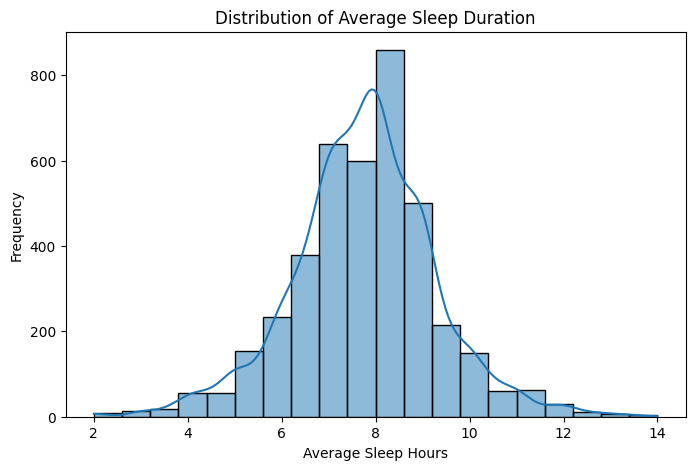

Skewness:  -0.041097223039341525


In [45]:
# Distribution of average sleep duration using a histogram
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Average_Sleep_Hours",
    bins=20,
    kde=True
)

plt.title("Distribution of Average Sleep Duration")
plt.xlabel("Average Sleep Hours")
plt.ylabel("Frequency")

plt.show()
print('Skewness: ',df["Average_Sleep_Hours"].skew())

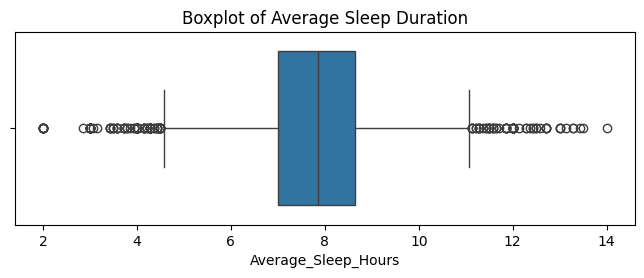

In [46]:
# Distribution of average sleep duration using a box plot
plt.figure(figsize=(8,2.5))

sns.boxplot(
    x=df["Average_Sleep_Hours"]
)

plt.title("Boxplot of Average Sleep Duration")

plt.show()

In [47]:
# Display the ranges and number of outliers
Q1 = df["Average_Sleep_Hours"].quantile(0.25)
Q3 = df["Average_Sleep_Hours"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Average_Sleep_Hours"] < lower) |
    (df["Average_Sleep_Hours"] > upper)
]

print("Lower limit:", lower)
print("Upper limit:", upper)
print("Number of outliers:", len(outliers))

Lower limit: 4.5357142857142865
Upper limit: 11.107142857142856
Number of outliers: 184


### Interpretation

The histogram showed that the distribution of `Average_Sleep_Hours` was approximately symmetric, which is consistent with the similarity between the mean (**7.79 hours**) and the median (**7.86 hours**). In addition, the skewness coefficient (**-0,03**) confirms that the distribution presents practically negligible skew.

The box plot identified **224 possible outliers** (approximately **4 %** of the sample), corresponding to participants who reported very short or very long average sleep durations. Since these values are plausible within the natural variability of sleep behavior and there is no evidence of recording or measurement errors, they were retained for subsequent analyses.

# Sleep duration categories

In order to facilitate interpretation and comparison of sleep duration, participants were classified into three categories following the recommendations of the National Sleep Foundation:

- **Short Sleep:** less than 7 hours per night.
- **Recommended Sleep:** between 7 and 9 hours per night.
- **Long Sleep:** more than 9 hours per night.

This categorical variable constitutes the primary grouping variable used in subsequent analyses, allowing comparison of health-related variables and lifestyle factors across the different sleep-duration groups.

In [48]:
# Frequency and percentage distribution of sleep duration categories

sleep_category = (
    df["Sleep_Duration_Category"]
    .value_counts(dropna=False)
    .rename("Count")
    .to_frame()
)

sleep_category["Percentage"] = (
    sleep_category["Count"] / len(df) * 100
).round(2)

print(sleep_category)

                         Count  Percentage
Sleep_Duration_Category                   
Recommended Sleep         2462       60.00
Short Sleep               1012       24.66
Long Sleep                 578       14.09
NaN                         51        1.24


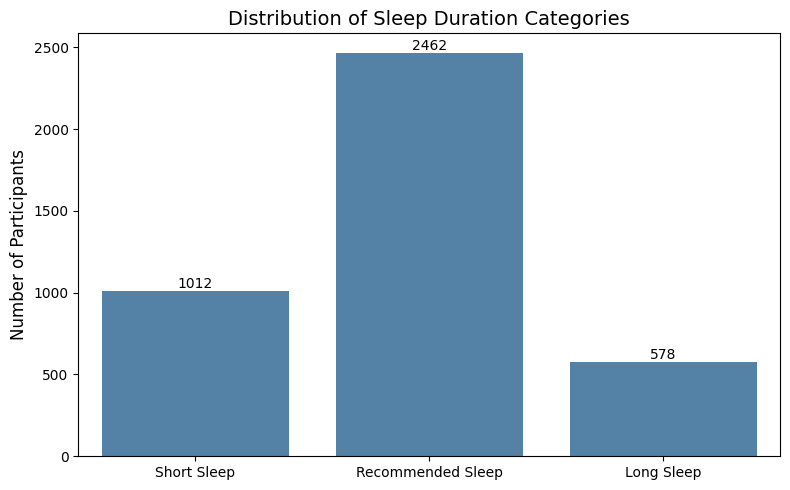

Sleep_Duration_Category
Short Sleep          1012
Recommended Sleep    2462
Long Sleep            578
dtype: int64


In [108]:
# Display participant distribution by sleep-duration category 
import matplotlib.pyplot as plt
import seaborn as sns

# Define the order of the sleep categories
order = [
    "Short Sleep",
    "Recommended Sleep",
    "Long Sleep"
]

# Create the figure
plt.figure(figsize=(8, 5))

# Create the bar chart
ax = sns.countplot(
    data=df,
    x="Sleep_Duration_Category",
    order=order,
    color="steelblue"
)

# Add the number of participants above each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

# Customize the graph
plt.title("Distribution of Sleep Duration Categories", fontsize=14)
#plt.xlabel("Sleep Duration Category", fontsize=12)
plt.xlabel('')
plt.ylabel("Number of Participants", fontsize=12)

plt.tight_layout()
plt.show()

print(df.groupby('Sleep_Duration_Category',observed=False).size())


### Interpretation

The majority of participants (**60,00 %**) reported sleeping between **7 and 9 hours per night**, which corresponds to the recommended sleep duration.

Approximately **24,66 %** of participants were classified as **Short Sleep**, while **14,09 %** were classified as **Long Sleep**. Only **1,24 %** of the observations had missing data for this variable.

Overall, these results indicate that, although most participants achieved the recommended sleep duration, a substantial proportion of the study population reported sleeping less or more than recommended. These sleep-duration categories will be used in subsequent analyses to investigate their association with demographic characteristics, health indicators, and lifestyle-related factors.

## Health Profile

With the aim of obtaining a more comprehensive assessment of participants' overall health status, a composite variable called **Health Profile** was created by combining four widely used clinical indicators: body mass index (BMI), glycosylated hemoglobin (HbA1c), blood pressure, and HDL cholesterol.

Each indicator was classified following recommendations from international organizations such as the World Health Organization (WHO), the American Diabetes Association (ADA), and the American Heart Association (AHA). All indicators contribute equally to the health assessment while preserving their clinical interpretation.

Each indicator was assigned **2 points** when it fell within a healthy range, **1 point** when it presented an intermediate risk (when applicable), and **0 points** when it was in an unfavorable range.

To reduce the loss of participants due to missing values in some biomarkers, the **Health Profile** was not calculated as a direct sum of points, but rather as the **percentage of the maximum possible score according to the indicators available for each participant**. In this way, each participant was evaluated using only the clinical information available. Those with **fewer than three clinical indicators available** were not classified.

| Clinical indicator | Guideline | Healthy (2) | Intermediate (1) | Unfavorable (0) |
|-------------------|------|---------------|----------------|------------------|
| BMI | WHO | Normal weight | Underweight / Overweight | Obesity |
| HbA1c | ADA | Normal | Prediabetes | Diabetes |
| Blood pressure | AHA/ACC | Normal | Elevated | Hypertension |
| HDL cholesterol | NHLBI / AHA | Normal | — | Low |

### Health Profile classification

| Percentage obtained | Health Profile |
|---------------------:|----------------|
| ≥ 80% | Good Health Profile |
| 50–79,99% | Intermediate Health Profile |
| < 50% | Poor Health Profile |

> **Note:** Participants with fewer than three clinical indicators available were classified as missing (`missing`) for this variable.

In [50]:
# ==========================
# Health Profile - Scoring
# ==========================

# BMI (WHO)
BMI_Points = np.select([df["BMI_Category"] == "Normal", df["BMI_Category"].isin(["Underweight", "Overweight"])
                        ,df["BMI_Category"] == "Obese"], [2,1,0], default=np.nan)

# HbA1c (ADA)
HbA1c_Points = np.select(
    [
        df["HbA1c"] < 5.7,
        (df["HbA1c"] >= 5.7) & (df["HbA1c"] < 6.5),
        df["HbA1c"] >= 6.5
    ],
    [2, 1, 0],
    default=np.nan
)

# Blood Pressure (AHA/ACC)
BP_Points = np.select(
    [
        (df["Systolic_BP"] < 120) &
        (df["Diastolic_BP"] < 80),

        (df["Systolic_BP"].between(120, 129)) &
        (df["Diastolic_BP"] < 80),

        (df["Systolic_BP"] >= 130) |
        (df["Diastolic_BP"] >= 80)
    ],
    [2, 1, 0],
    default=np.nan
)

# HDL Cholesterol (NHLBI/AHA)
HDL_Points = np.select(
    [
        ((df["Gender"] == "Male") & (df["HDL"] >= 40)) |
        ((df["Gender"] == "Female") & (df["HDL"] >= 50)),

        ((df["Gender"] == "Male") & (df["HDL"] < 40)) |
        ((df["Gender"] == "Female") & (df["HDL"] < 50))
    ],
    [2, 0],
    default=np.nan
)


In [51]:
# Use percentages to handle participants missing one of the four indicators 

# ==========================
# Health Profile Score
# ==========================

health_points = pd.DataFrame({
    "BMI": BMI_Points,
    "HbA1c": HbA1c_Points,
    "BP": BP_Points,
    "HDL": HDL_Points
})

# Sum of available points
obtained = health_points.sum(axis=1, skipna=True)

# Maximum possible score based on available variables
available = health_points.notna().sum(axis=1) * 2

# Percentage score (0–100)
df["Health_Profile_Percentage"] = (
    obtained / available * 100).round(2)

# Require at least 3 available indicators
df.loc[available < 6, "Health_Profile_Percentage"] = np.nan

# ==========================
# Health Profile Classification
# ==========================

df["Health_Profile"] = np.select(
    [
        df["Health_Profile_Percentage"] >= 80,
        df["Health_Profile_Percentage"].between(50, 79.99),
        df["Health_Profile_Percentage"] < 50
    ],
    [
        "Good Health Profile",
        "Intermediate Health Profile",
        "Poor Health Profile"
    ],
    default=None
)

display(df["Health_Profile"].value_counts(dropna=False))

Health_Profile
Intermediate Health Profile    1964
Poor Health Profile            1206
Good Health Profile             753
None                            180
Name: count, dtype: int64

## Interpretation

A total of **753 participants (18,35%)** were classified with a **Good Health Profile**, **1.964 (47,87%)** with an **Intermediate Health Profile**, and **1.206 (29,39%)** with a **Poor Health Profile**.

On the other hand, **180 participants (4,39%)** could not be classified because they had **fewer than three of the four clinical indicators** used to construct the *Health Profile* (`BMI`, `HbA1c`, `Blood Pressure` and `HDL Cholesterol`). This criterion was established to ensure that the classification was based on sufficient clinical information while minimizing the loss of participants due to missing values.

Overall, approximately **the 95,6% of the study population** could be classified into one of the three *Health Profile* categories. This indicates that the adopted methodology allowed for reduction of data loss without compromising the clinical validity of the composite variable. Moreover, the observed distribution reflects considerable variability in participants' general health status, providing an adequate basis to explore the association between sleep duration and health indicators in subsequent analyses.

## Lifestyle Profile

To summarize participants' lifestyle habits, a composite variable called **Lifestyle Profile** was created by combining three modifiable health behaviors: physical activity, smoking status, and alcohol consumption.

Physical activity was classified following the World Health Organization (WHO) recommendations, while smoking status and alcohol consumption were categorized using variables derived from the National Health and Nutrition Examination Survey (NHANES) and the corresponding guidance from the Centers for Disease Control and Prevention (CDC). The three indicators contributed equally to the evaluation of participants' lifestyle.

Sedentary time was intentionally excluded from this composite variable. Although prolonged sedentary behavior is recognized as an important health risk factor, current WHO recommendations do not establish universally accepted cutoffs to classify daily sedentary time into risk categories. To avoid introducing arbitrary thresholds, this variable was analyzed later independently as a continuous variable.

Each indicator was assigned **2 points** when representing the healthiest behavior, **1 point** for an intermediate behavior, and **0 points** for the least favorable behavior.

In order to reduce participant loss due to missing values in any lifestyle indicator, the **Lifestyle Profile** was not calculated as a direct sum of points, but rather as the **percentage of the maximum possible score according to the indicators available for each participant**. Thus, each participant was assessed using only the available lifestyle information. Those with **fewer than two of the three lifestyle indicators available** were not classified.

| Indicator | Guideline | Healthy (2) | Intermediate (1) | Unfavorable (0) |
|------------|------|---------------|----------------|------------------|
| Physical activity | WHO | Meets / Exceeds recommendation | Below recommendation | Inactive |
| Smoking status | CDC | Never smoker | Former smoker | Current smoker |
| Alcohol consumption | CDC (NHANES) | Never / Rare / Occasional | Former / Regular | Frequent / Daily |

### Lifestyle Profile classification

| Percentage obtained | Lifestyle Profile |
|---------------------:|-------------------|
| ≥ 80% | Healthy Lifestyle |
| 50–79,99% | Intermediate Lifestyle |
| < 50% | Unhealthy Lifestyle |

> **Note:** Participants with fewer than **two of the three lifestyle indicators available** were classified as missing (`missing`) for this variable.

## Physical activity scoring

Physical activity was scored following the World Health Organization (WHO) recommendations.

Participants who met or exceeded the recommended levels of physical activity received the highest score (**2 points**), those who performed some physical activity but below the recommendations received **1 point**, while inactive participants received **0 points**.

This scoring system reflects the degree of participants' adherence to the WHO weekly physical activity recommendations.

In [52]:
# Assign points according to the WHO physical activity recommendations
Physical_Activity_Points = np.select(
    [
        df["Physical_Activity_Level"].isin(
            ["Meets Recommendation", "Exceeds Recommendation"]
        ),
        df["Physical_Activity_Level"] == "Below Recommendation",
        df["Physical_Activity_Level"] == "Inactive"
    ],
    [2, 1, 0],
    default=np.nan
)

## Smoking habit scoring

Smoking habit was scored according to participants' current smoking status.

Participants who had never smoked received the highest score (**2 points**). Former smokers received **1 point**, since quitting smoking substantially reduces health risks over time, although prior tobacco exposure may still have long-term effects. Current smokers received **0 points** due to the well-established harmful health effects of active smoking.

In [53]:
# Assign points according to smoking status
Smoking_Points = np.select(
    [
        df["Smoking_Status"] == "Never smoker",
        df["Smoking_Status"] == "Former smoker",
        df["Smoking_Status"] == "Current smoker"
    ],
    [2, 1, 0],
    default=np.nan
)

## Alcohol consumption scoring

Alcohol consumption was scored according to frequency of consumption during the previous 12 months.

Participants who never consumed alcohol or who reported rare or occasional consumption received the highest score (**2 points**). Former consumers and regular consumers received an intermediate score (**1 point**). Participants with frequent or daily consumption received **0 points**, reflecting a less favorable consumption pattern.

Although moderate alcohol consumption has been debated in prior research, current public health recommendations increasingly emphasize minimizing alcohol intake, since no level of alcohol consumption can be considered completely risk-free.

In [54]:
# Assign points according to alcohol consumption frequency
Alcohol_Points = np.select(
    [
        df["Alcohol_Consumption"].isin(
            ["Never", "Rare", "Occasional"]
        ),
        df["Alcohol_Consumption"].isin(
            ["Former", "Regular"]
        ),
        df["Alcohol_Consumption"].isin(
            ["Frequent", "Daily"]
        )
    ],
    [2, 1, 0],
    default=np.nan
)

In [55]:
# ==========================
# Lifestyle Profile
# ==========================

# Combine all lifestyle scores
lifestyle_points = pd.DataFrame({
    "Smoking": Smoking_Points,
    "Alcohol": Alcohol_Points,
    "Physical_Activity": Physical_Activity_Points
})

# Calculate obtained and maximum possible scores
obtained = lifestyle_points.sum(axis=1, skipna=True)
available = lifestyle_points.notna().sum(axis=1) * 2

# Percentage score
df["Lifestyle_Profile_Percentage"] = (
    obtained / available * 100
).round(2)

# Require at least 2 of the 3 indicators
df.loc[
    available < 4,
    "Lifestyle_Profile_Percentage"
] = np.nan

# Lifestyle Profile classification
df["Lifestyle_Profile"] = np.select(
    [
        df["Lifestyle_Profile_Percentage"] >= 80,
        df["Lifestyle_Profile_Percentage"].between(50, 79.9999),
        df["Lifestyle_Profile_Percentage"] < 50
    ],
    [
        "Healthy Lifestyle",
        "Intermediate Lifestyle",
        "Unhealthy Lifestyle"
    ],
    default=None
)



In [56]:
# Classify participants according to their Lifestyle Profile
df["Lifestyle_Profile"] = np.select(
    [
        df["Lifestyle_Profile_Percentage"] >= 80,
        df["Lifestyle_Profile_Percentage"].between(50, 79.9999),
        df["Lifestyle_Profile_Percentage"] < 50
    ],
    [
        "Healthy Lifestyle",
        "Intermediate Lifestyle",
        "Unhealthy Lifestyle"
    ],
    default=None
)

display(df["Lifestyle_Profile"].value_counts(dropna=False))

Lifestyle_Profile
Intermediate Lifestyle    1893
Healthy Lifestyle         1249
Unhealthy Lifestyle        961
Name: count, dtype: int64

### Interpretation

The `Lifestyle_Profile` classification showed that **1.893 participants (46,14%)** were classified with an **Intermediate Lifestyle**, constituting the most frequent lifestyle group in the study population. A total of **1.249 participants (30,44%)** were classified with a **Healthy Lifestyle**, while **961 participants (23,42%)** were classified with an **Unhealthy Lifestyle**.

All **4.103 participants (100%)** could be classified into one of the three lifestyle categories. This was possible because the **Lifestyle Profile** was calculated as the percentage of the maximum possible score according to the lifestyle indicators available for each participant, requiring only the availability of **at least two of the three indicators**. Since all participants met this criterion, it was not necessary to exclude any observation from the classification.

Overall, the `Lifestyle_Profile` provides a comprehensive summary of participants' main modifiable lifestyle habits and will be used in subsequent analyses to investigate whether lifestyle is associated with sleep duration.

# Hypothesis-oriented analysis

Exploratory analysis allowed us to understand the composition of the study population and the distribution of the main variables. However, the primary objective of this project is to assess whether sleep duration is associated with demographic characteristics, health indicators, and lifestyle-related factors.

To ensure a structured, reproducible, and easy-to-interpret analysis, this section will follow a predefined analysis matrix. Rather than exploring all possible combinations of variables, each analysis will answer a specific research question directly related to the study hypothesis.

Each relationship will be analyzed following the same procedure:

1. Define the research question.
2. Identify the type of variables involved.
3. Select the most appropriate visualization.
4. Choose the corresponding statistical test.
5. Jointly interpret the graphical and statistical results.
6. Summarize the conclusions in relation to the stated hypothesis.

This approach provides a coherent workflow, facilitates interpretation of the results, and aligns the project with the methodology used in scientific studies.

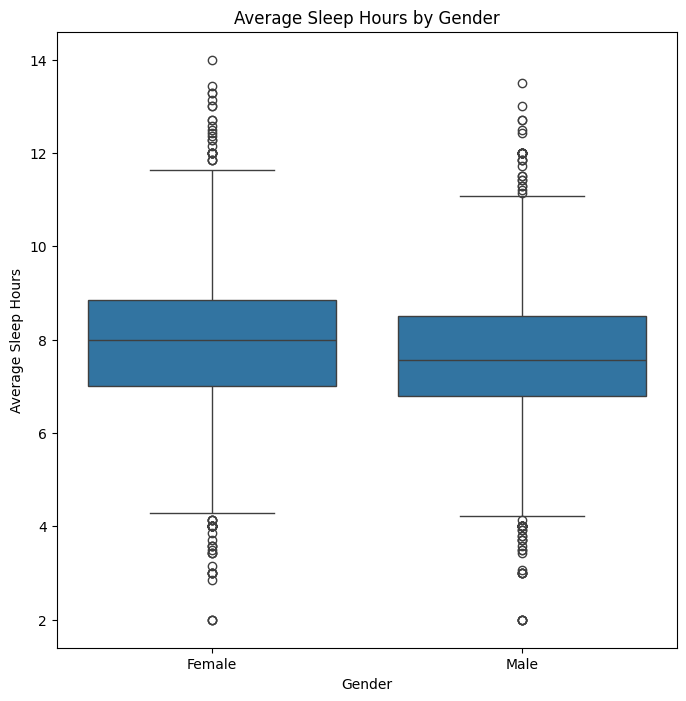

         count      mean       std  min       25%       50%       75%   max
Gender                                                                     
Female  2041.0  7.901519  1.517446  2.0  7.000000  8.000000  8.857143  14.0
Male    2011.0  7.595049  1.513607  2.0  6.785714  7.571429  8.500000  13.5


In [57]:
# Research question 1:
# Does average sleep duration differ between women and men?

# Research Question 1:
# Does average sleep duration differ between males and females?

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

sns.boxplot(
    data=df,
    x="Gender",
    y="Average_Sleep_Hours"
)

plt.title("Average Sleep Hours by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Sleep Hours")

plt.show()

print(df.groupby("Gender")["Average_Sleep_Hours"].describe())

### Interpretation

The boxplot shows that the distribution of average sleep duration is similar between women and men. On average, women have a slightly higher average sleep duration than men (approximately 18 minutes more).

The data dispersion is similar in both groups, although the interquartile range for women is slightly larger, indicating somewhat greater variability in the central 50% of observations. In addition, several outliers are observed in both groups, reflecting the presence of participants with unusually low or high sleep durations.

Overall, the plot suggests small descriptive differences between the sexes, with a broadly similar sleep distribution.

                             count      mean       std  min       25%  \
Age_Group                                                               
Young Adults (20–39)        1190.0  7.842317  1.427495  3.0  7.000000   
Middle-aged Adults (40–59)  1270.0  7.545107  1.425951  2.0  6.785714   
Older Adults (60+)          1592.0  7.842965  1.647247  2.0  7.000000   

                                 50%       75%        max  
Age_Group                                                  
Young Adults (20–39)        7.892857  8.642857  13.285714  
Middle-aged Adults (40–59)  7.571429  8.339286  13.142857  
Older Adults (60+)          8.000000  9.000000  14.000000  


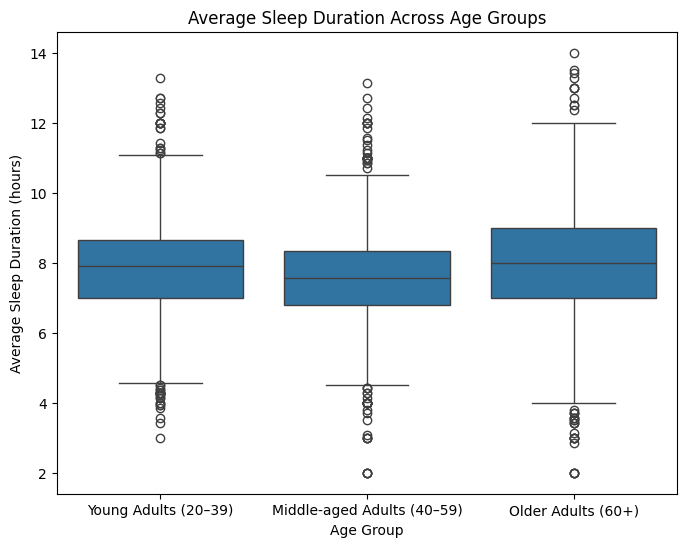

In [58]:
# Research Question 2:
# Does average sleep duration differ across age groups?

# Research question 2:
# Does average sleep duration differ across age groups?


# Create age groups

age_bins = [20, 40, 60, float("inf")]
age_labels = [
    "Young Adults (20–39)",
    "Middle-aged Adults (40–59)",
    "Older Adults (60+)"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

print(df.groupby('Age_Group',observed=False)['Average_Sleep_Hours'].describe())


plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Age_Group",
    y="Average_Sleep_Hours"
)

plt.title("Average Sleep Duration Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Average Sleep Duration (hours)")

plt.show()

### Interpretation

The three age categories show relatively similar distributions of sleep duration. However, middle-aged adults (40–59 years) exhibit slightly lower mean and median sleep durations than younger adults and older adults.

On the other hand, adults aged 60 years or older display greater variability in sleep duration, reflected by a wider interquartile range and greater data dispersion. Overall, the observed differences between groups are moderate, although middle-aged adults tend to sleep slightly less than the rest of the participants.

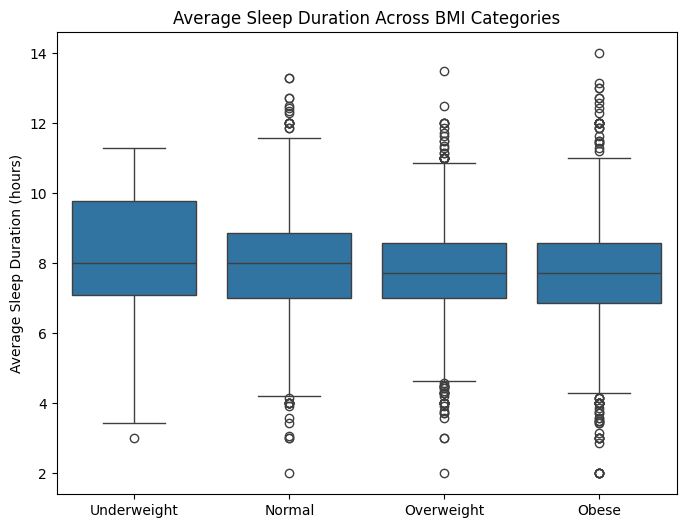

               count      mean       std  min       25%       50%       75%  \
BMI_Category                                                                  
Underweight     59.0  8.020581  1.917779  3.0  7.107143  8.000000  9.785714   
Normal         968.0  7.867695  1.538461  2.0  7.000000  8.000000  8.857143   
Overweight    1302.0  7.704740  1.420912  2.0  7.000000  7.714286  8.571429   
Obese         1674.0  7.691330  1.565885  2.0  6.857143  7.714286  8.571429   

                    max  
BMI_Category             
Underweight   11.285714  
Normal        13.285714  
Overweight    13.500000  
Obese         14.000000  


In [59]:
#Research Question 3:
# Does average sleep duration differ across Body Mass Index (BMI) categories?

# Research question 3:
# Does average sleep duration differ across BMI categories?

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="BMI_Category",
    y="Average_Sleep_Hours"
)

plt.title("Average Sleep Duration Across BMI Categories")
#plt.xlabel("BMI Category")
plt.xlabel("")
plt.ylabel("Average Sleep Duration (hours)")


plt.show()
print(df.groupby("BMI_Category",observed=False)["Average_Sleep_Hours"].describe())

### Interpretation

The four BMI categories present relatively similar distributions in average sleep duration. However, there is a slight decrease in average sleep duration as BMI category increases, with underweight individuals showing the highest mean and individuals with obesity showing the lowest.

The underweight group shows the greatest variability in sleep duration, reflected both in a larger interquartile range and a higher standard deviation compared to the other categories. Nevertheless, this group also has the smallest sample size (n = 59), so this greater dispersion should be interpreted with caution.

Overall, the differences between categories appear moderate and no very pronounced changes are observed in the distribution of sleep duration.

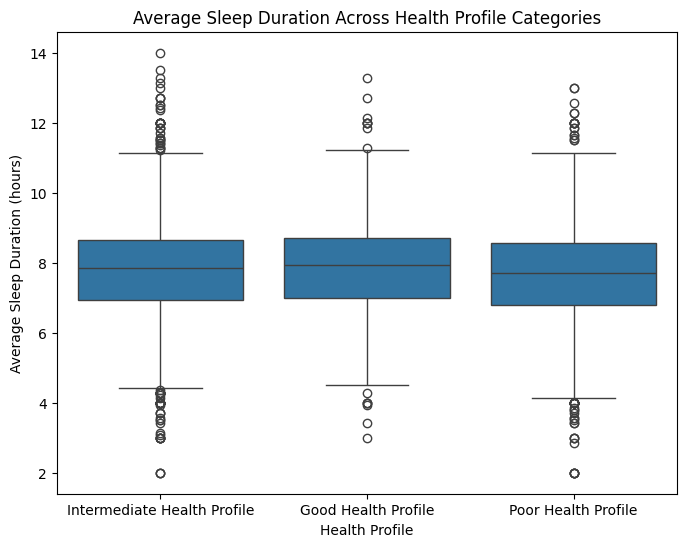

                              count      mean       std  min       25%  \
Health_Profile                                                           
Good Health Profile           746.0  7.878399  1.390775  3.0  7.000000   
Intermediate Health Profile  1937.0  7.757947  1.526713  2.0  6.928571   
Poor Health Profile          1193.0  7.628967  1.585768  2.0  6.785714   

                                  50%       75%        max  
Health_Profile                                              
Good Health Profile          7.928571  8.714286  13.285714  
Intermediate Health Profile  7.857143  8.642857  14.000000  
Poor Health Profile          7.714286  8.571429  13.000000  


In [60]:
# Research Question 4:
# Does average sleep duration differ across Health Profile categories?

# Research question 4:
# Does average sleep duration differ across Health Profile categories?



plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Health_Profile",
    y="Average_Sleep_Hours"
)

plt.title("Average Sleep Duration Across Health Profile Categories")
plt.xlabel("Health Profile")
plt.ylabel("Average Sleep Duration (hours)")

plt.show()

print(df.groupby('Health_Profile')['Average_Sleep_Hours'].describe())

### Interpretation

The three Health Profile categories present relatively similar distributions in sleep duration. However, there is a slight decrease in average sleep duration as health profile worsens, from 7.88 hours in the Good Health Profile group to 7.63 hours in the Poor Health Profile group.

The Good Health Profile group displays a slightly more homogeneous distribution of sleep duration, reflected both in a somewhat smaller interquartile range and in the lowest standard deviation (SD = 1.39). Conversely, the Poor Health Profile group shows greater data dispersion (SD = 1.59), although the differences in variability between groups are moderate.

Overall, the results suggest a trend toward shorter sleep duration and greater variability as health profile worsens.

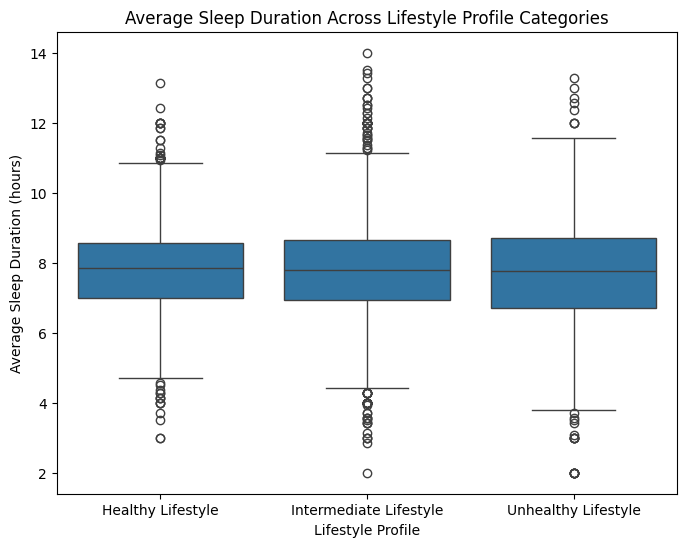

                         count      mean       std  min       25%       50%  \
Lifestyle_Profile                                                             
Healthy Lifestyle       1240.0  7.815726  1.304679  3.0  7.000000  7.857143   
Intermediate Lifestyle  1872.0  7.755800  1.547090  2.0  6.928571  7.785714   
Unhealthy Lifestyle      940.0  7.649240  1.725357  2.0  6.714286  7.750000   

                             75%        max  
Lifestyle_Profile                            
Healthy Lifestyle       8.571429  13.142857  
Intermediate Lifestyle  8.642857  14.000000  
Unhealthy Lifestyle     8.714286  13.285714  


In [61]:
# Research Question 5:
# Does average sleep duration differ across Lifestyle Profile categories?

# Research question 5:
# Does average sleep duration differ across Lifestyle Profile categories?


plt.figure(figsize=(8,6))
sns.boxplot(df,x='Lifestyle_Profile',y='Average_Sleep_Hours')

plt.xlabel("Lifestyle Profile")
plt.ylabel("Average Sleep Duration (hours)")
plt.title("Average Sleep Duration Across Lifestyle Profile Categories")
plt.show()

print(df.groupby("Lifestyle_Profile",observed=False)["Average_Sleep_Hours"].describe())

### Interpretation

The different Lifestyle Profile categories show, as in previous analyses, slight differences in average sleep duration that can be interpreted as a descriptive trend. In this case, it is observed that as lifestyle profile worsens, average sleep duration decreases slightly.

Participants with a **Healthy Lifestyle** have an average sleep duration of **7.82 hours**, while those with an **Unhealthy Lifestyle** record an average of **7.65 hours**, representing an approximate difference of **0.17 hours** (around **10 minutes**).

Regarding variability, the healthy lifestyle group shows the least dispersion in sleep duration (SD = **1.30**), whereas the unhealthy lifestyle group shows the greatest variability (SD = **1.73**), indicating greater heterogeneity in sleep patterns in the latter group.

Overall, although there is a trend toward shorter sleep duration and greater variability as lifestyle worsens, the observed differences are relatively small from a descriptive perspective. Inferential analyses will be necessary to determine whether these differences are statistically significant.

In [62]:
# Contingency table
health_sleep = pd.crosstab(
    df["Sleep_Duration_Category"],
    df["Health_Profile"]
)

display(health_sleep)

Health_Profile,Good Health Profile,Intermediate Health Profile,Poor Health Profile
Sleep_Duration_Category,,,
Short Sleep,158,488,330
Recommended Sleep,470,1181,704
Long Sleep,118,268,159


In [63]:
health_sleep_pct = pd.crosstab(
    df["Sleep_Duration_Category"],
    df["Health_Profile"],
    normalize="index"
) * 100

display(health_sleep_pct.round(1))



Health_Profile,Good Health Profile,Intermediate Health Profile,Poor Health Profile
Sleep_Duration_Category,,,
Short Sleep,16.2,50.0,33.8
Recommended Sleep,20.0,50.1,29.9
Long Sleep,21.7,49.2,29.2


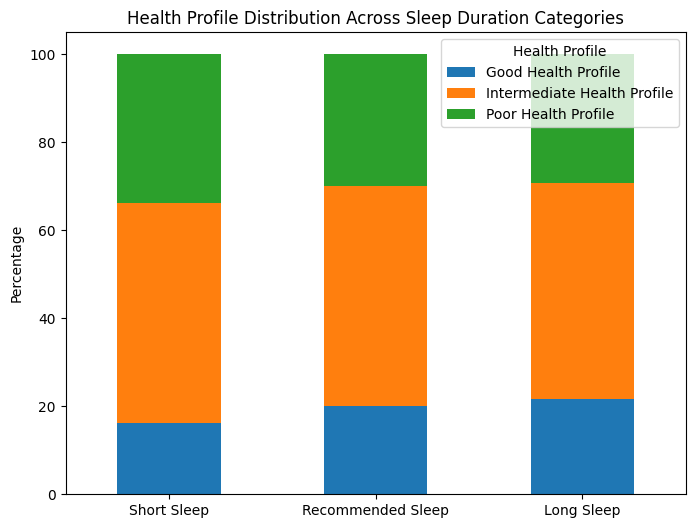

In [64]:
health_sleep_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6)
)

plt.ylabel("Percentage")
plt.title("Health Profile Distribution Across Sleep Duration Categories")
plt.legend(title="Health Profile")
plt.xticks(rotation=0)
plt.xlabel('')
plt.show()

### Relationship between sleep duration and health profile

The distribution of health profiles according to sleep duration shows a slight improvement as sleep duration increases.

Participants with **Short Sleep** showed the lowest proportion of individuals with a **Good Health Profile** (16,2%) and the highest proportion with a **Poor Health Profile** (33,8%). In comparison, the percentage of participants with a good health profile increased to **20,0%** in the **Recommended Sleep** category and to **21,7%** in **Long Sleep**. At the same time, the proportion of participants with an unfavorable health profile decreased from **33,8%** to **29,9%** and **29,2%**, respectively.

On the other hand, the proportion of participants with an **Intermediate Health Profile** remained virtually constant at around **50%** across the three sleep-duration categories.

Overall, these results suggest a **trend** toward a more favorable health profile as sleep duration increases. However, the **Intermediate Health Profile** remained the most frequent in all categories, and the proportion of participants with a **Poor Health Profile** continued to exceed that of those with a **Good Health Profile**, regardless of sleep duration.

# TESTS WITH THE ENGINE TO FIND INSIGHTS

In [65]:
#LIBRERIAS
import pandas as pd
import numpy as np

from scipy.stats import (
    chi2_contingency,
    kruskal,
    spearmanr,
    pearsonr
)


In [66]:
#BLOQUE 2 - VARIABLES
# Target variable
target = "Sleep_Duration_Category"


categorical_vars = [

    "Gender",
    "Race",
    "Education",
    "Marital_Status",
    "Age_Group",

    "Smoking_Status",
    "Alcohol_Consumption",

    "BMI_Category",

    "Physical_Activity_Level",

    "Reported_Sleep_Trouble_To_Doctor",
    "Snoring_Frequency",
    "Breathing_Interruptions_Frequency",
    "Daytime_Sleepiness_Frequency",

    "Health_Profile",
    "Lifestyle_Profile"

]


numeric_vars = [

    "Age",

    "Average_Sleep_Hours",

    "Sleep_Hours_Workdays",

    "Sleep_Hours_Weekend",

    "BMI",

    "Waist_Circumference",

    "Sedentary_Minutes_Per_Day",

    "Physical_Activity_Equivalent_Minutes_Week",

    "HbA1c",

    "HDL",

    "Systolic_BP",

    "Diastolic_BP",

    "Poverty_Index",

    "Health_Profile_Percentage",

    "Lifestyle_Profile_Percentage"

]

In [67]:
#BLOQUE 3 - CRAMER'S V
def cramers_v(contingency):

    chi2 = chi2_contingency(contingency)[0]

    n = contingency.sum().sum()

    r, c = contingency.shape

    return np.sqrt(chi2 / (n * (min(r - 1, c - 1))))

In [68]:
# BLOCK 4 - CATEGORICAL vs CATEGORICAL
categorical_results = []

for var in categorical_vars:

    temp = df[[target, var]].dropna()

    contingency = pd.crosstab(
        temp[target],
        temp[var]
    )

    chi2, p, dof, expected = chi2_contingency(contingency)

    cv = cramers_v(contingency)

    categorical_results.append({

        "Variable": var,

        "Test": "Chi-square",

        "Chi2": round(chi2,2),

        "p_value": round(p,5),

        "Cramers_V": round(cv,3),

        "N": len(temp)

    })

categorical_results = pd.DataFrame(categorical_results)

categorical_results.sort_values(
    "p_value",
    inplace=True
)

display(categorical_results)

,Variable,Test,Chi2,p_value,Cramers_V,N
0,Gender,Chi-square,36.49,0.00000,0.095,4052
1,Race,Chi-square,88.15,0.00000,0.104,4052
2,Education,Chi-square,80.28,0.00000,0.100,4044
4,Age_Group,Chi-square,40.51,0.00000,0.071,4052
12,Daytime_Sleepiness_Frequency,Chi-square,52.12,0.00000,0.080,4046
5,Smoking_Status,Chi-square,28.69,0.00001,0.059,4052
3,Marital_Status,Chi-square,39.40,0.00002,0.070,4048
7,BMI_Category,Chi-square,26.85,0.00015,0.058,4003
14,Lifestyle_Profile,Chi-square,20.92,0.00033,0.051,4052
9,Reported_Sleep_Trouble_To_Doctor,Chi-square,12.41,0.00202,0.055,4049


In [69]:
# BLOCK 5 - NUMERICAL vs SLEEP
numeric_results = []

for var in numeric_vars:

    temp = df[[target,var]].dropna()

    groups = [

        group[var].values

        for _, group in temp.groupby(target,observed=False)

    ]

    stat, p = kruskal(*groups)

    means = temp.groupby(target,observed=False)[var].mean()

    numeric_results.append({

        "Variable": var,

        "Test":"Kruskal",

        "Statistic": round(stat,2),

        "p_value": round(p,5),

        "Short_Mean": round(means.get("Short Sleep",np.nan),2),

        "Recommended_Mean": round(means.get("Recommended Sleep",np.nan),2),

        "Long_Mean": round(means.get("Long Sleep",np.nan),2),

        "N": len(temp)

    })

numeric_results = pd.DataFrame(numeric_results)

numeric_results.sort_values(
    "p_value",
    inplace=True
)

display(numeric_results)

,Variable,Test,Statistic,p_value,Short_Mean,Recommended_Mean,Long_Mean,N
1,Average_Sleep_Hours,Kruskal,3071.96,0.00000,5.86,7.96,10.14,4052
2,Sleep_Hours_Workdays,Kruskal,2863.98,0.00000,5.55,7.80,10.06,4052
3,Sleep_Hours_Weekend,Kruskal,1627.30,0.00000,6.64,8.37,10.34,4052
11,Diastolic_BP,Kruskal,26.38,0.00000,73.79,72.61,70.67,3910
12,Poverty_Index,Kruskal,64.14,0.00000,2.51,2.66,2.08,4047
14,Lifestyle_Profile_Percentage,Kruskal,17.63,0.00015,58.86,62.65,59.80,4052
4,BMI,Kruskal,16.42,0.00027,30.58,29.63,29.14,4003
7,Physical_Activity_Equivalent_Minutes_Week,Kruskal,13.84,0.00099,284.17,278.07,222.35,4052
8,HbA1c,Kruskal,12.75,0.00171,5.92,5.82,5.84,3887
5,Waist_Circumference,Kruskal,8.40,0.01499,102.21,100.57,99.46,3881


In [70]:
#BLOQUE 6 CORRELACIONES
correlations = []

for i in range(len(numeric_vars)):

    for j in range(i+1,len(numeric_vars)):

        var1 = numeric_vars[i]

        var2 = numeric_vars[j]

        temp = df[[var1,var2]].dropna()

        corr,p = spearmanr(
            temp[var1],
            temp[var2]
        )

        correlations.append({

            "Variable_1":var1,

            "Variable_2":var2,

            "Correlation":round(corr,3),

            "p_value":round(p,5)

        })

correlations = pd.DataFrame(correlations)

correlations["abs_corr"] = correlations["Correlation"].abs()

correlations = correlations.sort_values(
    "abs_corr",
    ascending=False
)

display(correlations.head(20))

,Variable_1,Variable_2,Correlation,p_value,abs_corr
14,Average_Sleep_Hours,Sleep_Hours_Workdays,0.956,0.0,0.956
50,BMI,Waist_Circumference,0.905,0.0,0.905
15,Average_Sleep_Hours,Sleep_Hours_Weekend,0.738,0.0,0.738
83,Physical_Activity_Equivalent_Minutes_Week,Lifestyle_Profile_Percentage,0.644,0.0,0.644
67,Waist_Circumference,Health_Profile_Percentage,-0.627,0.0,0.627
58,BMI,Health_Profile_Percentage,-0.615,0.0,0.615
88,HbA1c,Health_Profile_Percentage,-0.568,0.0,0.568
97,Systolic_BP,Health_Profile_Percentage,-0.547,0.0,0.547
27,Sleep_Hours_Workdays,Sleep_Hours_Weekend,0.536,0.0,0.536
93,HDL,Health_Profile_Percentage,0.525,0.0,0.525


In [71]:
# ALL VARIABLES AGAINST ALL VARIABLES 

all_categorical = categorical_vars + [target]

association_matrix = []

for i in range(len(all_categorical)):

    for j in range(i+1,len(all_categorical)):

        var1 = all_categorical[i]

        var2 = all_categorical[j]

        temp = df[[var1,var2]].dropna()

        contingency = pd.crosstab(
            temp[var1],
            temp[var2]
        )

        chi2,p,dof,expected = chi2_contingency(contingency)

        cv = cramers_v(contingency)

        association_matrix.append({

            "Variable_1":var1,

            "Variable_2":var2,

            "p_value":round(p,5),

            "Cramers_V":round(cv,3)

        })

association_matrix = pd.DataFrame(association_matrix)

association_matrix = association_matrix.sort_values(

    ["Cramers_V","p_value"],

    ascending=[False,True]

)

display(association_matrix.head(50))

,Variable_1,Variable_2,p_value,Cramers_V
97,Physical_Activity_Level,Lifestyle_Profile,0.0,0.473
73,Smoking_Status,Lifestyle_Profile,0.0,0.466
89,BMI_Category,Health_Profile,0.0,0.411
42,Marital_Status,Age_Group,0.0,0.374
82,Alcohol_Consumption,Lifestyle_Profile,0.0,0.347
105,Snoring_Frequency,Breathing_Interruptions_Frequency,0.0,0.253
15,Race,Education,0.0,0.239
5,Gender,Alcohol_Consumption,0.0,0.230
101,Reported_Sleep_Trouble_To_Doctor,Daytime_Sleepiness_Frequency,0.0,0.227
100,Reported_Sleep_Trouble_To_Doctor,Breathing_Interruptions_Frequency,0.0,0.217


# Exploration of Variability and Proportion of sleep categories 

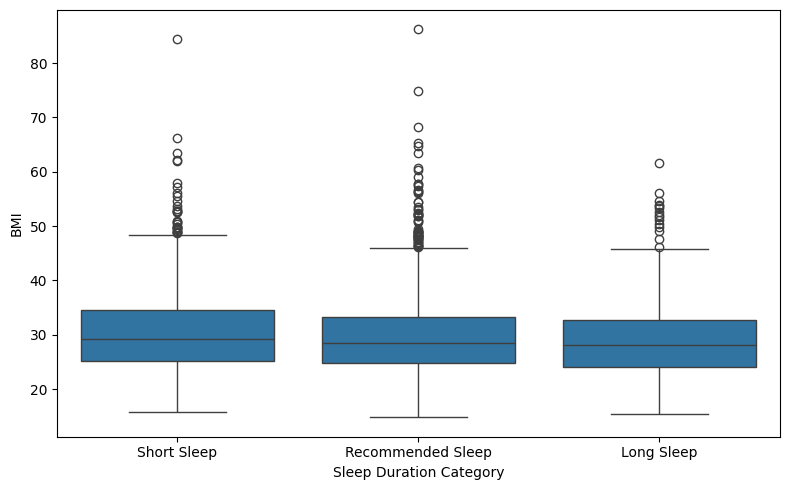

In [72]:
# BMI distribution across sleep-duration categories
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Sleep_Duration_Category",
    y="BMI",
    order=["Short Sleep","Recommended Sleep","Long Sleep"]
)

plt.xlabel("Sleep Duration Category")
plt.ylabel("BMI")
plt.tight_layout()

plt.show()

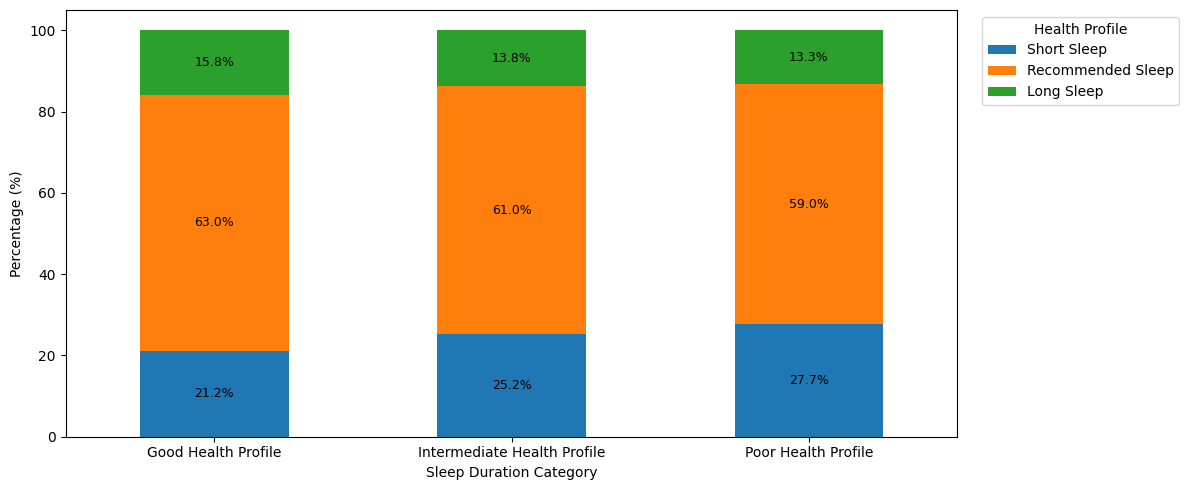

In [73]:
# Percentage distribution of sleep categories by Health Profile

import matplotlib.pyplot as plt

health_percent = (
    pd.crosstab(
        df["Health_Profile"],
        df["Sleep_Duration_Category"],
        normalize="index"
    ) * 100
).round(1)



ax = health_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(12,5)
)

plt.ylabel("Percentage (%)")
plt.xlabel("Sleep Duration Category")
plt.xticks(rotation=0)
plt.legend(title="Health Profile", bbox_to_anchor=(1.02,1), loc="upper left")

# Add labels
for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() > 3 else ""
        for bar in container
    ]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9)

plt.tight_layout()
plt.show()

## Research question 1

### Is shorter sleep duration associated with a poorer health profile?

To answer this question, the relationship between sleep-duration category and participants' health profile was analyzed. First, the percentage distribution of health profiles within each sleep-duration category was examined. Subsequently, the association between the two variables was statistically evaluated using the Chi-square test and Cramér's V coefficient.

Health_Profile,Good Health Profile,Intermediate Health Profile,Poor Health Profile
Sleep_Duration_Category,,,
Short Sleep,16.2,50.0,33.8
Recommended Sleep,20.0,50.1,29.9
Long Sleep,21.7,49.2,29.2


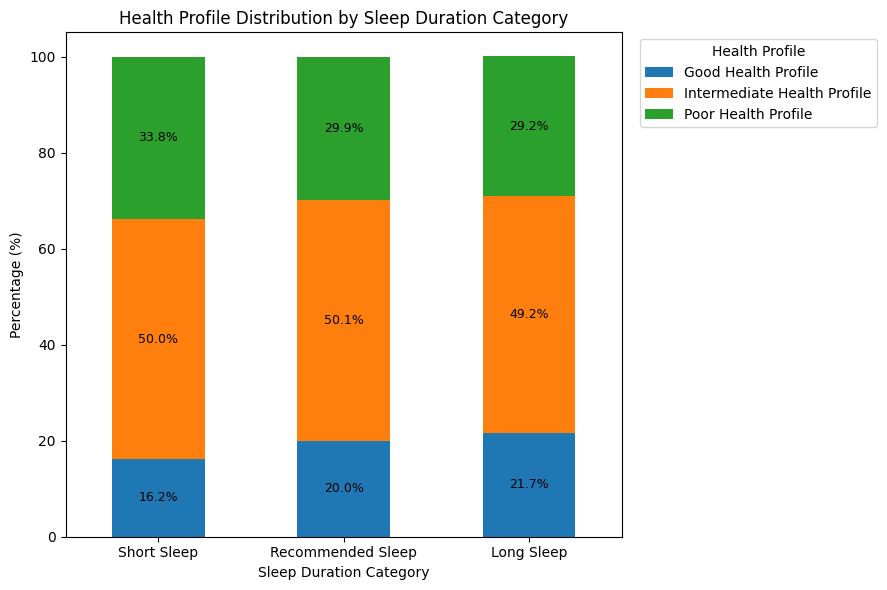

Statistical Results
Chi-square : 11.05
Degrees of freedom : 4
P-value : 0.0260
Cramer's V : 0.038


In [74]:
# ============================================================
# Research Question 1
# Is shorter sleep duration associated with a poorer health profile?
# ============================================================

import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

# ------------------------------------------------------------
# Percentage table
# ------------------------------------------------------------

health_percent = (
    pd.crosstab(
        df["Sleep_Duration_Category"],
        df["Health_Profile"],
        normalize="index"
    ) * 100
).round(1)

display(health_percent)

# ------------------------------------------------------------
# Percentage plot
# ------------------------------------------------------------

ax = health_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(9,6)
)

plt.title("Health Profile Distribution by Sleep Duration Category")
plt.xlabel("Sleep Duration Category")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.legend(
    title="Health Profile",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

# Add percentage labels

for container in ax.containers:

    labels = [

        f"{bar.get_height():.1f}%"
        if bar.get_height() > 3
        else ""

        for bar in container

    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Chi-square test
# ------------------------------------------------------------

contingency = pd.crosstab(
    df["Sleep_Duration_Category"],
    df["Health_Profile"]
)

chi2, p, dof, expected = chi2_contingency(contingency)

# ------------------------------------------------------------
# Cramer's V
# ------------------------------------------------------------

n = contingency.sum().sum()

r, c = contingency.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r - 1, c - 1))
)

print("=" * 40)
print("Statistical Results")
print("=" * 40)

print(f"Chi-square : {chi2:.2f}")
print(f"Degrees of freedom : {dof}")
print(f"P-value : {p:.4f}")
print(f"Cramer's V : {cramers_v:.3f}")

Health_Profile           Good Health Profile  Intermediate Health Profile  \
Sleep_Duration_Category                                                     
Short Sleep                             16.2                         50.0   
Recommended Sleep                       20.0                         50.1   
Long Sleep                              21.7                         49.2   

Health_Profile           Poor Health Profile  
Sleep_Duration_Category                       
Short Sleep                             33.8  
Recommended Sleep                       29.9  
Long Sleep                              29.2  


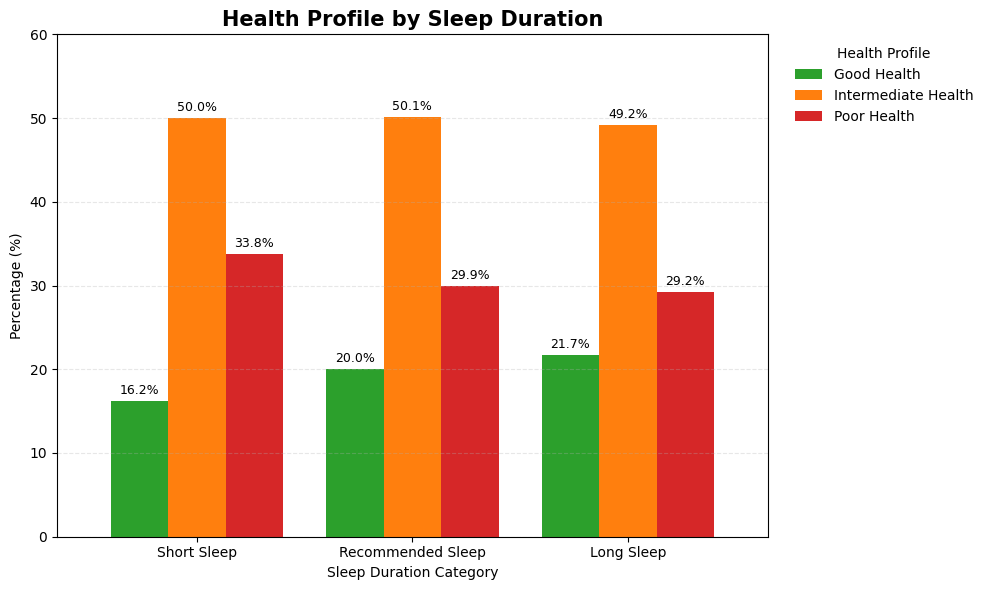

Statistical Results
Chi-square : 11.05
P-value    : 0.0260
Cramer's V : 0.038


In [75]:
# Presentation
# ============================================================
# Health Profile by Sleep Duration (Grouped Bar Chart)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

# ------------------------------------------------------------
# Percentage table
# ------------------------------------------------------------

health_percent = (
    pd.crosstab(
        df["Sleep_Duration_Category"],
        df["Health_Profile"],
        normalize="index"
    ) * 100
).round(1)

print(health_percent)

# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------

colors = {
    "Good Health Profile": "#2ca02c",          # Verde
    "Intermediate Health Profile": "#ff7f0e",  # Naranja
    "Poor Health Profile": "#d62728"           # Rojo
}
# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10,6))

health_percent.plot(
    kind="bar",
    ax=ax,
    color=colors,
    width=0.8
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_title(
    "Health Profile by Sleep Duration",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Sleep Duration Category")
ax.set_ylabel("Percentage (%)")

ax.set_ylim(0,60)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(rotation=0)

# ------------------------------------------------------------
# Labels on bars
# ------------------------------------------------------------

for container in ax.containers:

    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() >= 3
        else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

ax.legend(
    [
        "Good Health",
        "Intermediate Health",
        "Poor Health"
    ],
    title="Health Profile",
    frameon=False,
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Chi-square
# ------------------------------------------------------------

contingency = pd.crosstab(
    df["Sleep_Duration_Category"],
    df["Health_Profile"]
)

chi2, p, dof, expected = chi2_contingency(contingency)

# ------------------------------------------------------------
# Cramer's V
# ------------------------------------------------------------

n = contingency.values.sum()

r, c = contingency.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r-1, c-1))
)

print("="*40)
print("Statistical Results")
print("="*40)
print(f"Chi-square : {chi2:.2f}")
print(f"P-value    : {p:.4f}")
print(f"Cramer's V : {cramers_v:.3f}")

### Interpretation

The chart shows that differences between sleep-duration categories are not very pronounced; however, a consistent pattern can be observed. As health profile worsens from **Good Health Profile** to **Poor Health Profile**, the proportion of participants with **Short Sleep** increases slightly and the proportion of those with recommended sleep duration decreases.

This pattern is consistent with the results of the Chi-square test, which showed a statistically significant association between sleep duration and health profile (χ² = 11.05, *p* = 0.026). Nevertheless, the value of **Cramér's V = 0.038** indicates that the strength of this association is **very weak**, so although a trend exists, sleep duration alone explains only a small portion of the differences observed in participants' health profiles.

## Research question 2

### Is shorter sleep duration associated with a poorer lifestyle profile?

To answer this question, the relationship between sleep-duration category and participants' lifestyle profile was analyzed. First, the percentage distribution of lifestyle profiles within each sleep-duration category was examined. Subsequently, the association between the two variables was statistically evaluated using the Chi-square test and Cramér's V coefficient.

Lifestyle_Profile        Healthy Lifestyle  Intermediate Lifestyle  \
Sleep_Duration_Category                                              
Short Sleep                           26.9                    47.1   
Recommended Sleep                     33.1                    45.2   
Long Sleep                            26.5                    48.6   

Lifestyle_Profile        Unhealthy Lifestyle  
Sleep_Duration_Category                       
Short Sleep                             26.0  
Recommended Sleep                       21.6  
Long Sleep                              24.9  


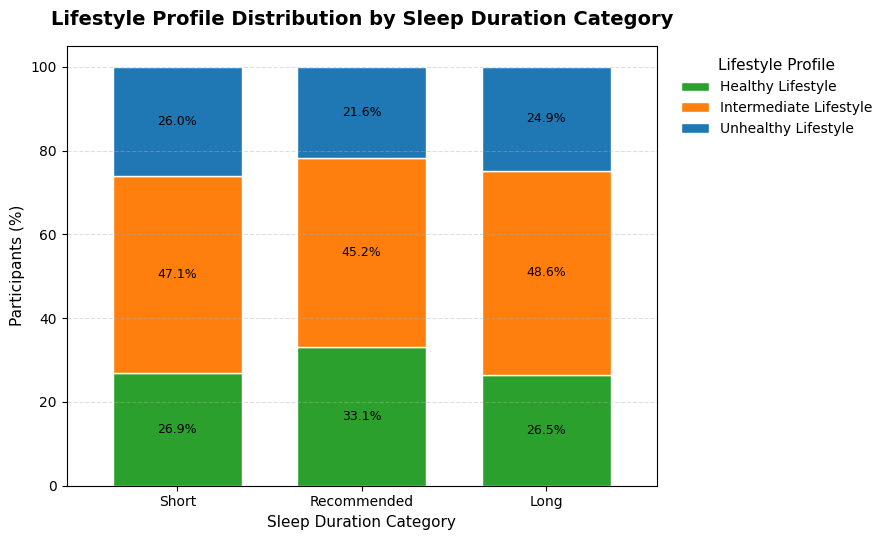

Chi-square test: χ²(4) = 20.92
P-value: 0.0003
Cramer's V: 0.051


In [76]:
# Percentage distribution of Lifestyle Profile by Sleep Duration Category
lifestyle_percent = (
    pd.crosstab(
        df["Sleep_Duration_Category"],
        df["Lifestyle_Profile"],
        normalize="index"
    ) * 100
).round(1)

# Order categories from healthiest to least healthy
lifestyle_percent = lifestyle_percent[
    [
        "Healthy Lifestyle",
        "Intermediate Lifestyle",
        "Unhealthy Lifestyle"
    ]
]

print(lifestyle_percent)

# Consistent project color palette


colors = [
     "#2ca02c",   # Verde Healthy Lifestyle
     "#ff7f0e",         # Naranja  recomend
     "#1f77b4"           # Azul   
]

# Create figure
fig, ax = plt.subplots(figsize=(9, 5.5))

lifestyle_percent.plot(
    kind="bar",
    stacked=True,
    color=colors,
    edgecolor="white",
    width=0.7,
    ax=ax
)

# Add percentage labels (only >= 5%)
for container in ax.containers:
    labels = [
        f"{value:.1f}%"
        if value >= 5 else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        color="black"
    )

# Formatting
ax.set_title(
    "Lifestyle Profile Distribution by Sleep Duration Category",
    fontsize=14,
    weight="bold",
    pad=15
)

ax.set_xlabel("Sleep Duration Category", fontsize=11)
ax.set_ylabel("Participants (%)", fontsize=11)

# Shorter x-axis labels
ax.set_xticklabels([
    "Short",
    "Recommended",
    "Long"
], rotation=0, fontsize=10)

ax.tick_params(axis="y", labelsize=10)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", visible=False)

# Legend
ax.legend(
    title="Lifestyle Profile",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.show()

# ----------------------------
# Chi-square Test
# ----------------------------
contingency_table = pd.crosstab(
    df["Sleep_Duration_Category"],
    df["Lifestyle_Profile"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramer's V
n = contingency_table.to_numpy().sum()
cramers_v = np.sqrt(
    chi2 / (n * (min(contingency_table.shape) - 1))
)

print(f"Chi-square test: χ²({dof}) = {chi2:.2f}")
print(f"P-value: {p:.4f}")
print(f"Cramer's V: {cramers_v:.3f}")

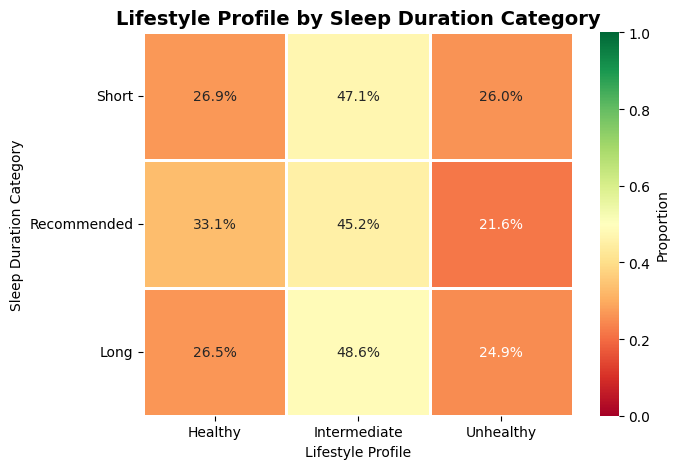

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Percentage distribution
lifestyle_percent = (
    pd.crosstab(
        df["Sleep_Duration_Category"],
        df["Lifestyle_Profile"],
        normalize="index"
    ) * 100
).round(1)

# Order rows
lifestyle_percent = lifestyle_percent[
    [
        "Healthy Lifestyle",
        "Intermediate Lifestyle",
        "Unhealthy Lifestyle"
    ]
]

# Normalize values (0–1) for the color scale
heatmap_data = lifestyle_percent / 100

# Plot
plt.figure(figsize=(7, 4.8))

ax = sns.heatmap(
    heatmap_data,
    annot=lifestyle_percent.astype(str) + "%",
    fmt="",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Proportion"}
)

# Labels
ax.set_title(
    "Lifestyle Profile by Sleep Duration Category",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel("Lifestyle Profile")
ax.set_ylabel("Sleep Duration Category")

ax.set_xticklabels(
    ["Healthy", "Intermediate", "Unhealthy"],
    rotation=0
)

ax.set_yticklabels(
    ["Short", "Recommended", "Long"],
    rotation=0
)

plt.tight_layout()
plt.show()

### Interpretation

The percentage distribution suggests a consistent, albeit subtle, relationship between sleep duration and lifestyle profile. Participants with a **recommended sleep duration** showed the highest proportion of **Healthy Lifestyle** (33.1%) and the lowest proportion of **Unhealthy Lifestyle** (21.6%). In contrast, participants with **Short Sleep** showed the lowest proportion of healthy lifestyles (26.9%) and the highest proportion of unhealthy lifestyles (26.0%). Participants with **Long Sleep** exhibited an intermediate pattern, with percentages closer to those observed in the short-sleep group.

The Chi-square test indicated a statistically significant association between sleep duration and lifestyle profile (χ²(4) = 20.92, *p* < 0.001). However, **Cramér's V = 0.051** indicates that the strength of this association is **very weak**. Therefore, although a relationship exists between the variables, sleep duration explains only a small part of the differences observed in participants' lifestyle profiles.

To better understand this association, the following sections will analyze the main components of the lifestyle profile individually, including smoking, physical activity level, and alcohol consumption.

### Physical activity level

To deepen the analysis of the relationship between sleep duration and lifestyle, the association between sleep-duration category and participants' physical activity level was analyzed. First, the percentage distribution of physical activity levels within each sleep-duration category was explored. Subsequently, the association between the two variables was evaluated using the Chi-square test and Cramér's V coefficient.

Physical_Activity_Level,Inactive,Below Recommendation,Meets Recommendation,Exceeds Recommendation
Sleep_Duration_Category,,,,
Short Sleep,45.8,14.5,11.1,28.6
Recommended Sleep,40.9,16.1,12.7,30.2
Long Sleep,48.4,15.7,12.6,23.2


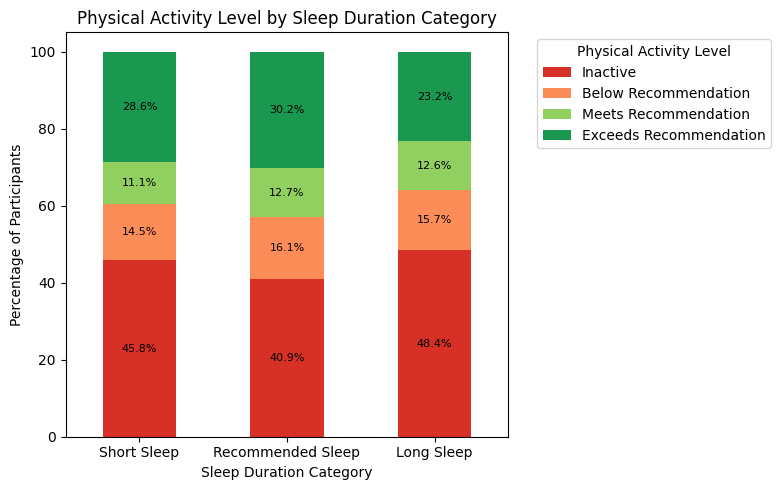

Chi-square test: χ²(6) = 19.11
P-value: 0.0040
Cramer's V: 0.049


In [78]:
# Percentage distribution of physical activity level by sleep duration category
pa_percent = (
    pd.crosstab(
        df["Sleep_Duration_Category"],
        df["Physical_Activity_Level"],
        normalize="index"
    ) * 100
).round(1)

display(pa_percent)

colors = [
    "#d73027",  # Inactive
    "#fc8d59",  # Below Recommendation
    "#91cf60",  # Meets Recommendation
    "#1a9850"   # Exceeds Recommendation
]

# Create stacked percentage bar chart
ax = pa_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=colors
)


# Add percentage labels
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value > 0 else ""
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8)

# Customize chart
plt.title("Physical Activity Level by Sleep Duration Category")
plt.xlabel("Sleep Duration Category")
plt.ylabel("Percentage of Participants")
plt.xticks(rotation=0)
plt.legend(
    title="Physical Activity Level",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

# Chi-square test
contingency_table = pd.crosstab(
    df["Sleep_Duration_Category"],
    df["Physical_Activity_Level"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

# Calculate Cramer's V
n = contingency_table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

# Print statistical results
print(f"Chi-square test: χ²({dof}) = {chi2:.2f}")
print(f"P-value: {p:.4f}")
print(f"Cramer's V: {cramers_v:.3f}")

### Interpretation

The percentage distribution shows a subtle relationship between sleep duration and physical activity level. Participants with a **recommended sleep duration** exhibited the lowest proportion of inactive individuals (40.9%) and the highest proportion of participants exceeding the physical activity recommendations (30.2%). In contrast, participants with **Long Sleep** showed the highest proportion of inactive individuals (48.4%) and the lowest proportion of participants exceeding the recommendations (23.2%). The **Short Sleep** group displayed an intermediate pattern.

The Chi-square test indicated a statistically significant association between sleep duration and physical activity level (χ²(6) = 19.11, *p* = 0.004). However, **Cramér's V = 0.049** indicates that the strength of this association is **very weak**. Therefore, although physical activity level varies across sleep-duration categories, the magnitude of these differences is small.

Overall, these results suggest that participants with a recommended sleep duration tend to exhibit a more favorable physical activity pattern, whereas those with prolonged sleep duration show a greater tendency toward physical inactivity.

### Smoking status

To continue analyzing the components of the lifestyle profile, the relationship between sleep-duration category and participants' smoking status was examined. First, the percentage distribution of the different smoking categories within each sleep-duration category was explored. Subsequently, the association between the two variables was evaluated using the Chi-square test and Cramér's V coefficient.

Smoking_Status           Current smoker  Former smoker  Never smoker
Sleep_Duration_Category                                             
Short Sleep                        24.0           23.9          52.1
Recommended Sleep                  16.4           24.6          59.0
Long Sleep                         18.0           24.4          57.6


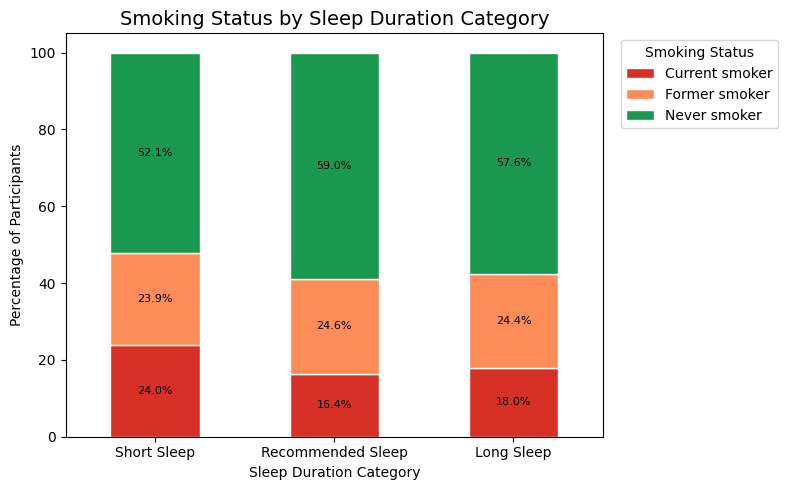

Chi-square test: χ²(4) = 28.69
P-value: 0.0000
Cramer's V: 0.059


In [79]:
# Percentage distribution of smoking status by sleep duration category
smoking_percent = (
    pd.crosstab(
        df["Sleep_Duration_Category"],
        df["Smoking_Status"],
        normalize="index"
    ) * 100
).round(1)

print(smoking_percent)

# Color palette (healthier → greener)
colors = [
    "#d73027",  # Current smoker (red)
    "#fc8d59",  # Former smoker (orange)
    "#1a9850"   # Never smoker (green)
]

# Create stacked percentage bar chart
ax = smoking_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=colors,
    edgecolor="white"
)

# Add percentage labels
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value >= 5 else ""
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8)

# Customize chart
plt.title("Smoking Status by Sleep Duration Category", fontsize=14)
plt.xlabel("Sleep Duration Category")
plt.ylabel("Percentage of Participants")
plt.xticks(rotation=0)
plt.legend(
    title="Smoking Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

# Chi-square test
contingency_table = pd.crosstab(
    df["Sleep_Duration_Category"],
    df["Smoking_Status"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

# Calculate Cramer's V
n = contingency_table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

# Print statistical results
print(f"Chi-square test: χ²({dof}) = {chi2:.2f}")
print(f"P-value: {p:.4f}")
print(f"Cramer's V: {cramers_v:.3f}")

### Interpretation

The percentage distribution shows a consistent relationship between sleep duration and smoking status. Participants with a **recommended sleep duration** exhibited the highest proportion of **Never smokers** (59.0%) and the lowest proportion of **Current smokers** (16.4%). In contrast, participants with **Short Sleep** showed the highest proportion of current smokers (24.0%) and the lowest proportion of individuals who had never smoked (52.1%). Participants with **Long Sleep** displayed an intermediate pattern.

The Chi-square test indicated a statistically significant association between sleep duration and smoking status (χ²(4) = 28.69, *p* < 0.001). However, **Cramér's V = 0.059** indicates that the strength of this association is **very weak**. Therefore, although smoking status varies across sleep-duration categories, the magnitude of these differences is small.

Overall, these results suggest that participants with a recommended sleep duration present a more favorable smoking profile, while those with short sleep duration have a higher proportion of current smokers.

### Alcohol consumption

To complete the analysis of the lifestyle profile, the relationship between sleep-duration category and participants' level of alcohol consumption was examined. First, the percentage distribution of the different alcohol-consumption categories within each sleep-duration category was explored. Subsequently, the association between the two variables was evaluated using the Chi-square test and Cramér's V coefficient.

Alcohol_Consumption,Never,Former,Rare,Occasional,Regular,Frequent,Daily
Sleep_Duration_Category,,,,,,,
Short Sleep,11.5,24.8,12.7,20.7,16.8,6.4,7.1
Recommended Sleep,12.1,24.0,11.7,21.4,16.8,6.8,7.1
Long Sleep,14.5,31.5,12.3,18.0,10.7,5.0,8.0


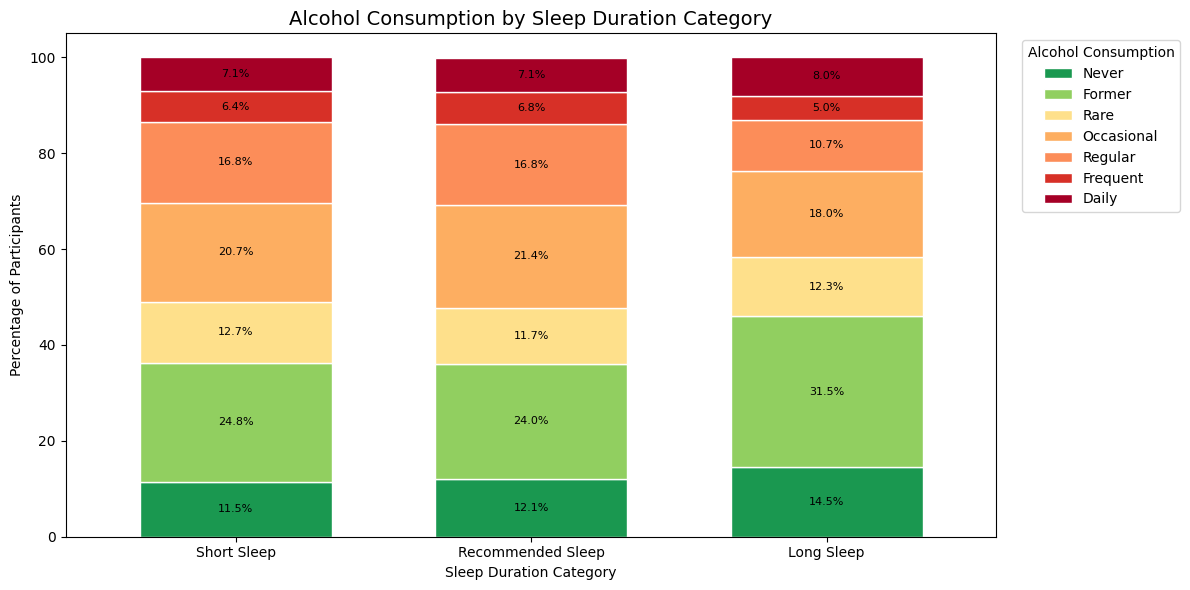

Chi-square test: χ²(12) = 30.90
P-value: 0.0020
Cramer's V: 0.062


In [80]:
# Percentage distribution of alcohol consumption by sleep duration category
alcohol_percent = (
    pd.crosstab(
        df["Sleep_Duration_Category"],
        df["Alcohol_Consumption"],
        normalize="index"
    ) * 100
).round(1)

display(alcohol_percent)

# Color palette
colors = [
    "#1a9850",  # Never
    "#91cf60",  # Former
    "#fee08b",  # Rare
    "#fdae61",  # Occasional
    "#fc8d59",  # Regular
    "#d73027",  # Frequent
    "#a50026"   # Daily
]

# Create stacked percentage bar chart
ax = alcohol_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=colors,
    width=0.65,
    edgecolor="white"
)

# Add percentage labels
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value >= 5 else ""
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8)

# Customize chart
plt.title("Alcohol Consumption by Sleep Duration Category", fontsize=14)
plt.xlabel("Sleep Duration Category")
plt.ylabel("Percentage of Participants")
plt.xticks(rotation=0)

plt.legend(
    title="Alcohol Consumption",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Chi-square test
contingency_table = pd.crosstab(
    df["Sleep_Duration_Category"],
    df["Alcohol_Consumption"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

# Calculate Cramer's V
n = contingency_table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

# Print statistical results
print(f"Chi-square test: χ²({dof}) = {chi2:.2f}")
print(f"P-value: {p:.4f}")
print(f"Cramer's V: {cramers_v:.3f}")

### Interpretation

The percentage distribution shows modest differences in alcohol-consumption patterns across the sleep-duration categories. Participants with **Long Sleep** exhibited a higher proportion of **Former drinkers** (31.5%) and a lower proportion of **Regular drinkers** (10.7%) compared with the other sleep-duration groups. In contrast, the distributions for **Short Sleep** and **Recommended Sleep** were relatively similar across most alcohol-consumption categories.

The Chi-square test indicated a statistically significant association between sleep duration and alcohol consumption (χ²(12) = 30.90, *p* = 0.002). However, **Cramér's V = 0.062** indicates that the strength of this association is **weak**. Therefore, although alcohol-consumption patterns vary across sleep-duration categories, the magnitude of these differences is limited.

Overall, these results suggest that alcohol consumption is associated with sleep duration. Nevertheless, the strength of this relationship is relatively weak and should be interpreted with caution.

### Snoring frequency

To investigate a possible relationship between sleep duration and sleep-related symptoms, the association between sleep-duration category and snoring frequency was analyzed. First, the percentage distribution of snoring frequency within each sleep-duration category was explored. Subsequently, the association between the two variables was evaluated using the Chi-square test and Cramér's V coefficient.

Snoring_Frequency,Never,Rarely (1-2 nights/week),Occasionally (3-4 nights/week),Frequently (5+ nights/week)
Sleep_Duration_Category,,,,
Short Sleep,23.6,22.9,20.3,33.2
Recommended Sleep,27.0,24.7,20.4,27.9
Long Sleep,27.1,22.7,16.8,33.4


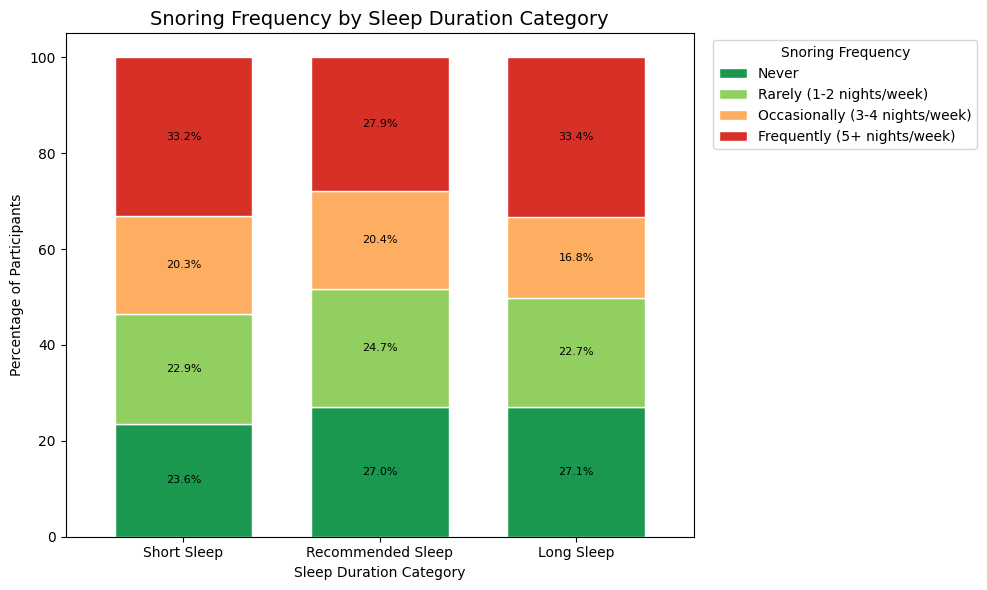

Chi-square test: χ²(6) = 16.07
P-value: 0.0134
Cramer's V: 0.046


In [81]:
# Percentage distribution of snoring frequency by sleep duration category
snoring_percent = (
    pd.crosstab(
        df["Sleep_Duration_Category"],
        df["Snoring_Frequency"],
        normalize="index"
    ) * 100
).round(1)

# Reorder categories from lowest to highest frequency
snoring_percent = snoring_percent[
    [
        "Never",
        "Rarely (1-2 nights/week)",
        "Occasionally (3-4 nights/week)",
        "Frequently (5+ nights/week)"
    ]
]

display(snoring_percent)

# Color palette
colors = [
    "#1a9850",  # Never
    "#91cf60",  # Rarely
    "#fdae61",  # Occasionally
    "#d73027"   # Frequently
]

# Create stacked percentage bar chart
ax = snoring_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    width=0.7,
    color=colors,
    edgecolor="white"
)

# Add percentage labels
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value >= 5 else ""
        for value in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8
    )

# Customize chart
plt.title("Snoring Frequency by Sleep Duration Category", fontsize=14)
plt.xlabel("Sleep Duration Category")
plt.ylabel("Percentage of Participants")
plt.xticks(rotation=0)

plt.legend(
    title="Snoring Frequency",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Chi-square test
contingency_table = pd.crosstab(
    df["Sleep_Duration_Category"],
    df["Snoring_Frequency"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

# Calculate Cramer's V
n = contingency_table.to_numpy().sum()
cramers_v = np.sqrt(
    chi2 / (n * (min(contingency_table.shape) - 1))
)

# Print statistical results
print(f"Chi-square test: χ²({dof}) = {chi2:.2f}")
print(f"P-value: {p:.4f}")
print(f"Cramer's V: {cramers_v:.3f}")

### Interpretation

The percentage distribution shows modest differences in snoring frequency across sleep-duration categories. Participants with **Recommended Sleep** had the lowest proportion of individuals reporting frequent snoring (27.9%), whereas the **Short Sleep** (33.2%) and **Long Sleep** (33.4%) groups showed similar and higher percentages of frequent snoring. In the other snoring-frequency categories, relatively small differences were observed between the three sleep-duration groups.

The Chi-square test indicated a statistically significant association between sleep duration and snoring frequency (χ²(6) = 16.07, *p* = 0.013). However, **Cramér's V = 0.046** indicates that the strength of this association is **very weak**. Therefore, although snoring frequency varies across sleep-duration categories, the magnitude of these differences is limited.

Overall, these results suggest that participants with a recommended sleep duration have a lower proportion of frequent snoring compared with those who sleep less or more than recommended. Nevertheless, the observed relationship between sleep duration and snoring frequency is weak.

### Frequency of breathing interruptions during sleep

To deepen the analysis of sleep-related problems, the association between sleep-duration category and the frequency of breathing interruptions during sleep was examined. First, the percentage distribution of breathing-interruption frequency within each sleep-duration category was explored. Subsequently, the association between the two variables was evaluated using the Chi-square test and Cramér's V coefficient.

Breathing_Interruptions_Frequency  Never  Rarely (1-2 nights/week)  \
Sleep_Duration_Category                                              
Short Sleep                         72.0                      14.2   
Recommended Sleep                   76.8                      11.5   
Long Sleep                          74.0                      12.2   

Breathing_Interruptions_Frequency  Occasionally (3-4 nights/week)  \
Sleep_Duration_Category                                             
Short Sleep                                                   6.1   
Recommended Sleep                                             6.7   
Long Sleep                                                    8.0   

Breathing_Interruptions_Frequency  Frequently (5+ nights/week)  
Sleep_Duration_Category                                         
Short Sleep                                                7.8  
Recommended Sleep                                          4.9  
Long Sleep                                 

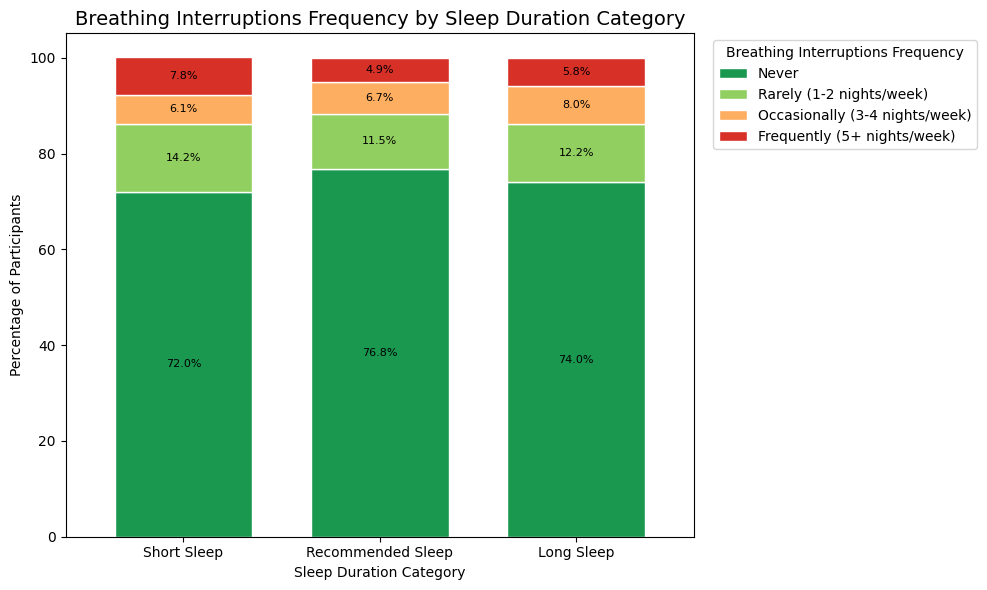

Chi-square test: χ²(6) = 17.27
P-value: 0.0083
Cramer's V: 0.048


In [82]:
# Percentage distribution of breathing interruptions by sleep duration category
breathing_percent = (
    pd.crosstab(
        df["Sleep_Duration_Category"],
        df["Breathing_Interruptions_Frequency"],
        normalize="index"
    ) * 100
).round(1)

# Reorder categories from lowest to highest frequency
breathing_percent = breathing_percent[
    [
        "Never",
        "Rarely (1-2 nights/week)",
        "Occasionally (3-4 nights/week)",
        "Frequently (5+ nights/week)"
    ]
]

print(breathing_percent)

# Color palette
colors = [
    "#1a9850",  # Never
    "#91cf60",  # Rarely
    "#fdae61",  # Occasionally
    "#d73027"   # Frequently
]

# Create stacked percentage bar chart
ax = breathing_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    width=0.7,
    color=colors,
    edgecolor="white"
)

# Add percentage labels
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value >= 1 else ""
        for value in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8
    )

# Customize chart
plt.title("Breathing Interruptions Frequency by Sleep Duration Category", fontsize=14)
plt.xlabel("Sleep Duration Category")
plt.ylabel("Percentage of Participants")
plt.xticks(rotation=0)

plt.legend(
    title="Breathing Interruptions Frequency",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Chi-square test
contingency_table = pd.crosstab(
    df["Sleep_Duration_Category"],
    df["Breathing_Interruptions_Frequency"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

# Calculate Cramer's V
n = contingency_table.to_numpy().sum()
cramers_v = np.sqrt(
    chi2 / (n * (min(contingency_table.shape) - 1))
)

# Print statistical results
print(f"Chi-square test: χ²({dof}) = {chi2:.2f}")
print(f"P-value: {p:.4f}")
print(f"Cramer's V: {cramers_v:.3f}")

### Interpretation

The percentage distribution shows modest differences in the frequency of breathing interruptions across sleep-duration categories. Participants with **Recommended Sleep** had the highest proportion of individuals reporting **never** experiencing breathing interruptions during sleep (76.8%) and the lowest proportion of those experiencing them **frequently** (4.9%). In comparison, the **Short Sleep** and **Long Sleep** groups showed slightly higher percentages of frequent breathing interruptions.

The Chi-square test indicated a statistically significant association between sleep duration and breathing-interruption frequency (χ²(6) = 17.27, *p* = 0.008). However, **Cramér's V = 0.048** indicates that the strength of this association is **very weak**. Therefore, although the frequency of breathing interruptions varies across sleep-duration categories, the magnitude of these differences is limited.

Overall, these results suggest that participants with a recommended sleep duration show a slightly more favorable pattern regarding breathing interruptions during sleep. Nevertheless, the observed relationship between the two variables is weak and should be interpreted with caution.

In [83]:
df
display(df.groupby('Marital_Status')['Average_Sleep_Hours'].mean().sort_values(ascending=False).round(2))

Marital_Status
Widowed                8.02
Living with partner    7.83
Never married          7.76
Married                7.73
Separated              7.65
Divorced               7.58
Name: Average_Sleep_Hours, dtype: float64

### Sleep problems reported to a health professional

With the aim of evaluating whether sleep duration is related to the perception of sleep problems that require medical attention, the association between sleep-duration category and having reported sleep problems to a health professional was examined. First, the percentage distribution of this variable within each sleep-duration category was explored. Subsequently, the association between the two variables was evaluated using the Chi-square test and Cramér's V coefficient.

Reported_Sleep_Trouble_To_Doctor    No   Yes
Sleep_Duration_Category                     
Short Sleep                       67.2  32.8
Recommended Sleep                 73.1  26.9
Long Sleep                        70.4  29.6


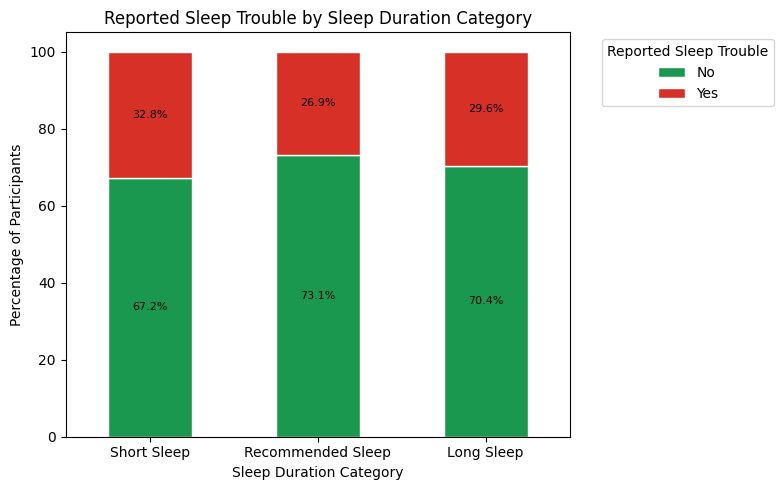

Chi-square test: χ²(2) = 12.41
P-value: 0.0020
Cramer's V: 0.055


In [84]:
# Percentage distribution of reported sleep trouble by sleep duration category
sleep_trouble_percent = (
    pd.crosstab(
        df["Sleep_Duration_Category"],
        df["Reported_Sleep_Trouble_To_Doctor"],
        normalize="index"
    ) * 100
).round(1)

# Reorder categories
sleep_trouble_percent = sleep_trouble_percent[
    [
        "No",
        "Yes"
    ]
]

print(sleep_trouble_percent)

# Color palette
colors = [
    "#1a9850",  # No
    "#d73027"   # Yes
]

# Create stacked percentage bar chart
ax = sleep_trouble_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=colors,
    edgecolor="white"
)

# Add percentage labels
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value > 0 else ""
        for value in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8
    )

# Customize chart
plt.title("Reported Sleep Trouble by Sleep Duration Category")
plt.xlabel("Sleep Duration Category")
plt.ylabel("Percentage of Participants")
plt.xticks(rotation=0)

plt.legend(
    title="Reported Sleep Trouble",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Chi-square test
contingency_table = pd.crosstab(
    df["Sleep_Duration_Category"],
    df["Reported_Sleep_Trouble_To_Doctor"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

# Calculate Cramer's V
n = contingency_table.to_numpy().sum()
cramers_v = np.sqrt(
    chi2 / (n * (min(contingency_table.shape) - 1))
)

print(f"Chi-square test: χ²({dof}) = {chi2:.2f}")
print(f"P-value: {p:.4f}")
print(f"Cramer's V: {cramers_v:.3f}")

### Interpretation

The percentage distribution shows moderate differences in the proportion of participants who reported having consulted a health professional for sleep problems according to sleep-duration category. Participants with **Short Sleep** had the highest percentage of individuals who had reported sleep problems to a health professional (32.8%), whereas those with **Recommended Sleep** had the lowest percentage (26.9%). The **Long Sleep** group had an intermediate proportion (29.6%).

The Chi-square test indicated a statistically significant association between sleep duration and having reported sleep problems to a health professional (χ²(2) = 12.41, *p* = 0.002). However, **Cramér's V = 0.055** indicates that the strength of this association is **very weak**. This suggests that although participants with short sleep report sleep problems to a health professional more frequently, the magnitude of the association is limited.

Overall, these results support the hypothesis that sleep duration below the recommended level is associated with a higher probability of reporting sleep problems to a health professional. Nevertheless, the strength of this relationship is small and should be interpreted cautiously.

### Frequency of daytime sleepiness

Finally, the association between sleep-duration category and the frequency with which participants experienced daytime sleepiness was analyzed. First, the percentage distribution of daytime-sleepiness frequency within each sleep-duration category was explored. Subsequently, the association between the two variables was evaluated using the Chi-square test and Cramér's V coefficient.

Daytime_Sleepiness_Frequency  Never  Rarely (1 time/month)  \
Sleep_Duration_Category                                      
Short Sleep                    13.7                   22.1   
Recommended Sleep              17.0                   25.3   
Long Sleep                     18.0                   21.5   

Daytime_Sleepiness_Frequency  Sometimes (2-4 times/month)  \
Sleep_Duration_Category                                     
Short Sleep                                          32.3   
Recommended Sleep                                    34.6   
Long Sleep                                           32.9   

Daytime_Sleepiness_Frequency  Often (5-15 times/month)  \
Sleep_Duration_Category                                  
Short Sleep                                       18.6   
Recommended Sleep                                 16.5   
Long Sleep                                        18.0   

Daytime_Sleepiness_Frequency  Almost always (16-30 times/month)  
Sleep_Duration_Category   

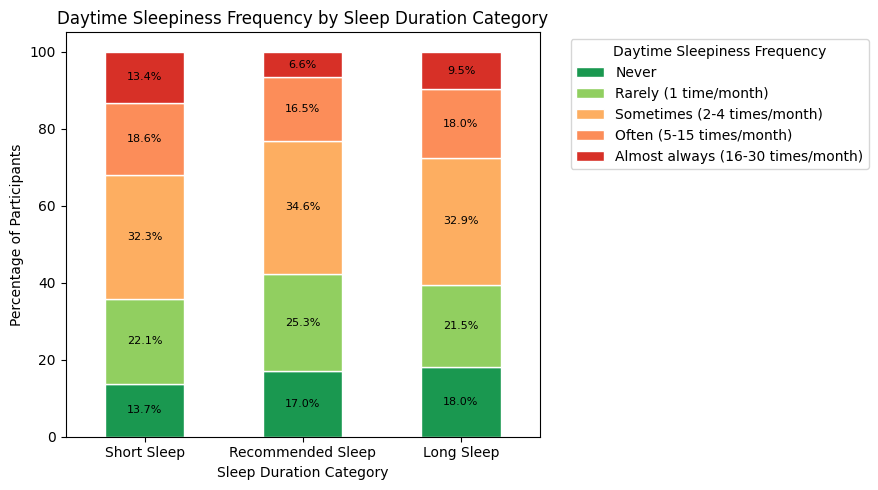

Chi-square test: χ²(8) = 52.12
P-value: 0.0000
Cramer's V: 0.080


In [85]:
# Percentage distribution of daytime sleepiness frequency by sleep duration category
sleepiness_percent = (
    pd.crosstab(
        df["Sleep_Duration_Category"],
        df["Daytime_Sleepiness_Frequency"],
        normalize="index"
    ) * 100
).round(1)

# Reorder categories
sleepiness_percent = sleepiness_percent[
    [
        "Never",
        "Rarely (1 time/month)",
        "Sometimes (2-4 times/month)",
        "Often (5-15 times/month)",
        "Almost always (16-30 times/month)"
    ]
]

print(sleepiness_percent)

# Color palette (least to most frequent)
colors = [
    "#1a9850",  # Never
    "#91cf60",  # Rarely
    "#fdae61",  # Sometimes
    "#fc8d59",  # Often
    "#d73027"   # Almost always
]

# Create stacked percentage bar chart
ax = sleepiness_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    color=colors,
    edgecolor="white"
)

# Add percentage labels
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value > 0 else ""
        for value in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8
    )

# Customize chart
plt.title("Daytime Sleepiness Frequency by Sleep Duration Category")
plt.xlabel("Sleep Duration Category")
plt.ylabel("Percentage of Participants")
plt.xticks(rotation=0)

plt.legend(
    title="Daytime Sleepiness Frequency",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Chi-square test
contingency_table = pd.crosstab(
    df["Sleep_Duration_Category"],
    df["Daytime_Sleepiness_Frequency"]
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

# Calculate Cramer's V
n = contingency_table.to_numpy().sum()
cramers_v = np.sqrt(
    chi2 / (n * (min(contingency_table.shape) - 1))
)

# Print statistical results
print(f"Chi-square test: χ²({dof}) = {chi2:.2f}")
print(f"P-value: {p:.4f}")
print(f"Cramer's V: {cramers_v:.3f}")

### Interpretation

The percentage distribution shows differences in the frequency of daytime sleepiness across sleep-duration categories. Participants with **Long Sleep** had the highest proportion of individuals who **never** experienced daytime sleepiness (18.0%). However, participants with **Recommended Sleep** showed the lowest proportion of those who experienced daytime sleepiness **almost always** (6.6%), while the **Short Sleep** group had the highest percentage of very frequent daytime sleepiness (13.4%).

The Chi-square test indicated a statistically significant association between sleep duration and daytime-sleepiness frequency (χ²(8) = 52.12, *p* < 0.001). **Cramér's V = 0.080** indicates that the strength of this association is **weak**, although it represents the strongest association observed among the sleep-problem–related variables analyzed in this study.

Overall, these results suggest that sleep duration is associated with the frequency of daytime sleepiness. In particular, participants with **Short Sleep** had a higher proportion of very frequent daytime sleepiness, whereas those with **Recommended Sleep** showed the lowest proportion of this pattern. Although the magnitude of the association remains limited, this finding supports the hypothesis that sleep duration is related to daytime functioning.

# Research Question 4: Demographic Factors

## Which demographic factors are associated with sleep duration among U.S. adults?

This section investigates whether demographic characteristics are associated with sleep duration categories. For each demographic variable, the analysis includes a contingency table, percentage distribution, Chi-square test of independence, Cramer's V effect size, and an appropriate visualization. The objective is to identify which demographic factors show the strongest association with sleep duration among participants in the NHANES 2017–2018 dataset.

In [86]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def analyze_categorical(df, variable, target="Sleep_Duration_Category"):
    """
    Perform a categorical association analysis between a predictor
    and the sleep duration category.
    """

    # Remove missing values
    data = df[[variable, target]].dropna()

    # Contingency table
    contingency = pd.crosstab(data[variable], data[target])

    # Percentage table
    percentages = (
        pd.crosstab(
            data[variable],
            data[target],
            normalize="index"
        ) * 100
    ).round(1)
    
    frequencies = (
    data[variable]
    .value_counts()
    .sort_index()
    )

    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency)

    # Cramer's V
    n = contingency.values.sum()
    cramers_v = np.sqrt(
        chi2 / (n * (min(contingency.shape) - 1))
    )

    return {
    "frequencies": frequencies,
    "contingency": contingency,
    "percentages": percentages,
    "chi2": chi2,
    "p": p,
    "dof": dof,
    "cramers_v": cramers_v,
    "expected": expected
    }

### Gender

The variable **Gender** was analyzed to evaluate whether the distribution of sleep-duration categories differs between men and women. To do this, a contingency table with row percentages was constructed and the Chi-square test of independence was applied along with Cramér's V statistic to measure the strength of the association. In addition, a violin plot was used to compare the distribution of average sleep hours between the two genders.

In [87]:
gender = analyze_categorical(df, "Gender")
print(gender["contingency"])

Sleep_Duration_Category  Short Sleep  Recommended Sleep  Long Sleep
Gender                                                             
Female                           439               1263         339
Male                             573               1199         239


In [88]:
print(gender["percentages"])

Sleep_Duration_Category  Short Sleep  Recommended Sleep  Long Sleep
Gender                                                             
Female                          21.5               61.9        16.6
Male                            28.5               59.6        11.9


In [89]:
print(f"Chi-square : {gender['chi2']:.2f}")
print(f"Degrees of freedom : {gender['dof']}")
print(f"p-value : {gender['p']:.4f}")
print(f"Cramer's V : {gender['cramers_v']:.3f}")

Chi-square : 36.49
Degrees of freedom : 2
p-value : 0.0000
Cramer's V : 0.095


In [90]:
print(df.groupby("Gender")["Average_Sleep_Hours"].describe())

         count      mean       std  min       25%       50%       75%   max
Gender                                                                     
Female  2041.0  7.901519  1.517446  2.0  7.000000  8.000000  8.857143  14.0
Male    2011.0  7.595049  1.513607  2.0  6.785714  7.571429  8.500000  13.5


C:\Users\aleja\AppData\Local\Temp\ipykernel_20272\3621613634.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


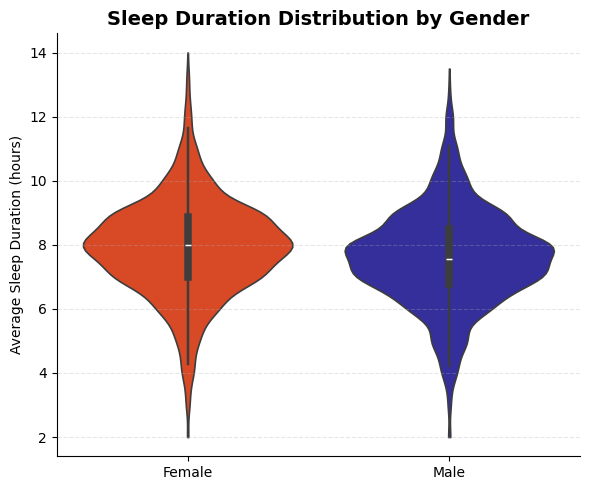

In [91]:
# Presentation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

ax = sns.violinplot(
    data=df,
    x="Gender",
    y="Average_Sleep_Hours",
    palette=["#F53809", "#241DAD"],
    inner="box",      # Show the box plot (median and quartiles)
    cut=0,
    linewidth=1.2
)

plt.title(
    "Sleep Duration Distribution by Gender",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Average Sleep Duration (hours)")

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

The analysis showed a statistically significant association between gender and sleep-duration categories (χ² = 36.49, *p* < 0.001). Men had a higher proportion of **Short Sleep** (28.5%) compared with women (21.5%), while women showed slightly higher percentages in both **Recommended Sleep** (61.9% vs. 59.6%) and **Long Sleep** (16.6% vs. 11.9%).

However, the effect size was **very weak** (Cramér's V = 0.095), which indicates that although a statistically significant association exists between gender and sleep duration, it explains only a small part of the observed differences.

The violin plot complements these results by showing that the distribution of average sleep hours is very similar between genders. Nevertheless, the female distribution is slightly shifted toward higher values, with a mean (7.90 h) and a median (8.00 h) greater than those observed in men (7.60 h and 7.57 h, respectively). In addition, variability was practically identical in both groups (SD ≈ 1.51 h), suggesting similar sleep patterns, although women tend to sleep slightly more on average.

### Age group

The variable **Age_Group_10** was analyzed to evaluate whether the distribution of sleep-duration categories differs across age groups. To do this, a contingency table with row percentages was constructed and the Chi-square test of independence was applied along with Cramér's V statistic to measure the strength of the association.

In [92]:
bins = [20, 30, 40, 50, 60, 70, 81]
labels = ["20–29", "30–39", "40–49", "50–59", "60–69", "70–80"]

df["Age_Group_10"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=False
)

analyze_categorical(df, "Age_Group_10")

{'frequencies': Age_Group_10
 20–29    578
 30–39    612
 40–49    582
 50–59    688
 60–69    838
 70–80    754
 Name: count, dtype: int64,
 'contingency': Sleep_Duration_Category  Short Sleep  Recommended Sleep  Long Sleep
 Age_Group_10                                                       
 20–29                            116                364          98
 30–39                            157                371          84
 40–49                            169                353          60
 50–59                            202                421          65
 60–69                            229                483         126
 70–80                            139                470         145,
 'percentages': Sleep_Duration_Category  Short Sleep  Recommended Sleep  Long Sleep
 Age_Group_10                                                       
 20–29                           20.1               63.0        17.0
 30–39                           25.7               60.6        13.7


In [93]:
print(df["Age_Group_10"].value_counts().sort_index())
age = analyze_categorical(df, "Age_Group_10")
print(age["percentages"])

Age_Group_10
20–29    583
30–39    623
40–49    586
50–59    696
60–69    849
70–80    766
Name: count, dtype: int64
Sleep_Duration_Category  Short Sleep  Recommended Sleep  Long Sleep
Age_Group_10                                                       
20–29                           20.1               63.0        17.0
30–39                           25.7               60.6        13.7
40–49                           29.0               60.7        10.3
50–59                           29.4               61.2         9.4
60–69                           27.3               57.6        15.0
70–80                           18.4               62.3        19.2


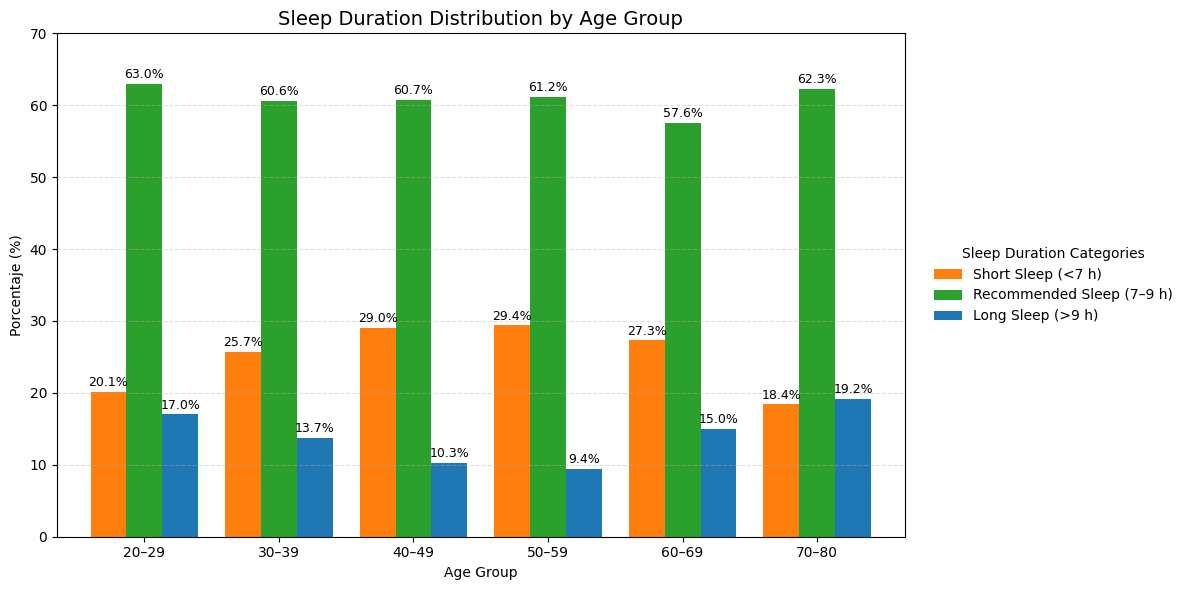

In [94]:
# For the presentation
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))


colors = {
    "Recommended Sleep": "#2ca02c",   # Verde
    "Short Sleep": "#ff7f0e",         # Naranja
    "Long Sleep": "#1f77b4"           # Azul
}

age["percentages"].plot(
    kind="bar",
    ax=ax,
    width=0.8,
    color=[colors[col] for col in age["percentages"].columns]
)

# Add percentage labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9, padding=2)

# Title and labels
ax.set_title("Sleep Duration Distribution by Age Group", fontsize=14)
ax.set_xlabel("Age Group")
ax.set_ylabel("Porcentaje (%)")
ax.set_ylim(0, 70)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Custom legend
ax.legend(
    ["Short Sleep (<7 h)",
        "Recommended Sleep (7–9 h)",

        "Long Sleep (>9 h)"
    ],
    title="Sleep Duration Categories",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [95]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Contingency table
# ------------------------------------------------------------

contingency = pd.crosstab(
    df["Age_Group"],
    df["Sleep_Duration_Category"]
)

# ------------------------------------------------------------
# Chi-square test
# ------------------------------------------------------------

chi2, p, dof, expected = chi2_contingency(contingency)

# ------------------------------------------------------------
# Cramer's V
# ------------------------------------------------------------

n = contingency.values.sum()

r, c = contingency.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r - 1, c - 1))
)

print("="*40)
print("Statistical Results")
print("="*40)
print(f"Chi-square : {chi2:.2f}")
print(f"P-value    : {p:.4f}")
print(f"Cramer's V : {cramers_v:.3f}")

Statistical Results
Chi-square : 40.51
P-value    : 0.0000
Cramer's V : 0.071


### Interpretation

The chart shows that differences between the sleep-duration categories are not very pronounced; however, a consistent pattern can be observed. As the health profile shifts from **Good Health Profile** to **Poor Health Profile**, the proportion of participants with **Short Sleep** increases slightly and the proportion of those with recommended sleep duration decreases.

This pattern is consistent with the results of the Chi-square test, which showed a statistically significant association between sleep duration and health profile (χ² = 11.05, *p* = 0.026). Nevertheless, the value of **Cramér's V = 0.038** indicates that the strength of this association is **very weak**, so although a trend exists, sleep duration by itself explains only a small part of the differences observed in participants' health profiles.

To better understand this relationship, the following sections will analyze health indicators individually, such as BMI, waist circumference and HbA1c.

### Distribution of Sleep Duration by Age Group

The distribution of sleep-duration categories shows different patterns according to age group. First, the proportion of participants with a **recommended sleep duration** remains relatively stable across age groups, hovering around 60%. However, a more pronounced decrease is observed in the **60–69 years** group (57.6%), followed by a recovery in the **70–80 years** group (62.3%).

Regarding the **Short Sleep** category, there is an upward trend from the **20–29 years** group (20.1%) to its peak in the **50–59 years** group (29.4%). After that age, the proportion decreases progressively to **18.4%** in the **70–80 years** group.

By contrast, the **Long Sleep** category shows the opposite pattern. Its percentage decreases from **17.0%** in the **20–29 years** group to a minimum of **9.4%** in the **50–59 years** group, and then increases again to **19.2%** in the **70–80 years** group.

Overall, these results suggest that the **Short Sleep** and **Long Sleep** categories follow opposite trends across age groups, while the proportion of participants with a **recommended sleep duration** remains relatively constant during adulthood.

### Race / Ethnicity

This analysis evaluates whether sleep duration differs among the sample's racial and ethnic groups. First, the distribution of participants by race/ethnicity is presented, followed by a heatmap showing the percentage of each sleep-duration category within each group. Finally, the Chi-square test of independence and Cramér's V statistic are applied to evaluate statistical significance and association strength between race/ethnicity and sleep duration.

In [96]:
race_results = analyze_categorical(df_analysis, "Race")

In [97]:
# Frequency table
display(race_results["contingency"].sum(axis=1))

Race
Mexican American         730
Non-Hispanic Asian       807
Non-Hispanic Black      1276
Non-Hispanic White      1909
Other / Multi-Racial     267
Other Hispanic           511
dtype: int64

In [98]:
# Contingency table
display(race_results["contingency"])

Sleep_Duration_Category,Short Sleep,Recommended Sleep,Long Sleep
Race,,,
Mexican American,146,458,126
Non-Hispanic Asian,155,556,96
Non-Hispanic Black,418,658,200
Non-Hispanic White,395,1241,273
Other / Multi-Racial,78,141,48
Other Hispanic,121,309,81


In [99]:
# Row percentages
display(race_results["percentages"])

Sleep_Duration_Category,Short Sleep,Recommended Sleep,Long Sleep
Race,,,
Mexican American,20.0,62.7,17.3
Non-Hispanic Asian,19.2,68.9,11.9
Non-Hispanic Black,32.8,51.6,15.7
Non-Hispanic White,20.7,65.0,14.3
Other / Multi-Racial,29.2,52.8,18.0
Other Hispanic,23.7,60.5,15.9


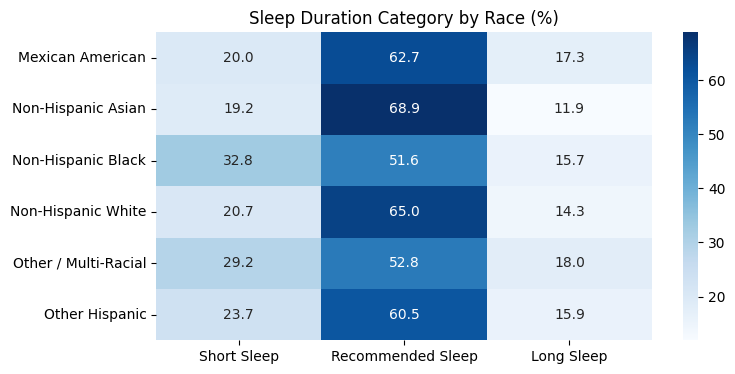

In [100]:
import seaborn as sns

plt.figure(figsize=(8,4))

sns.heatmap(
    race_results["percentages"],
    annot=True,
    cmap="Blues",
    fmt=".1f"
)

plt.title("Sleep Duration Category by Race (%)")
plt.xlabel("")
plt.ylabel("")
plt.show()

In [101]:
print(f"Chi²: {race_results['chi2']:.2f}")
print(f"p-value: {race_results['p']:.4f}")
print(f"Cramer's V: {race_results['cramers_v']:.3f}")

Chi²: 111.06
p-value: 0.0000
Cramer's V: 0.100


### Interpretation

The heatmap shows appreciable differences in the distribution of sleep duration across racial and ethnic groups. **Non-Hispanic Asian** participants had the highest proportion of **Recommended Sleep** (68.9%) and the lowest proportion of **Short Sleep** (19.2%), suggesting the most favorable sleep pattern among the groups analyzed. In contrast, **Non-Hispanic Black** participants showed the highest prevalence of **Short Sleep** (32.8%) and the lowest proportion of **Recommended Sleep** (51.6%), reflecting a relatively less favorable sleep pattern. The remaining racial and ethnic groups had intermediate distributions, with only moderate differences observed in the proportion of **Long Sleep**.

The Chi-square test showed a statistically significant association between race/ethnicity and sleep-duration category (χ² = 111.06, *p* < 0.001). However, the effect size was **weak** (Cramér's V = 0.100), indicating that although differences exist among racial and ethnic groups, race/ethnicity explains only a small portion of the variability observed in sleep duration within the studied population.

### Poverty Index

The Poverty Income Ratio (PIR) was categorized into quintiles to facilitate analysis of its relationship with sleep duration. Quintiles divide participants into five groups of approximately equal sample size, from the lowest to the highest values of the index. A higher Poverty Index value indicates a relatively better socioeconomic situation with respect to the federal poverty threshold.

The distribution of sleep-duration categories across these quintiles was analyzed using contingency tables, percentage distributions, stacked bar charts and the Chi-square test of independence. The association strength was evaluated with Cramér's V statistic.

In [102]:
df_analysis["Poverty_Group"] = pd.qcut(
    df_analysis["Poverty_Index"],
    q=5,
    labels=[
    "Lowest",
    "Low",
    "Middle",
    "High",
    "Highest"
    ]
)

print(df_analysis["Poverty_Group"].value_counts().sort_index())

Poverty_Group
Lowest     1115
Low        1123
Middle     1098
High       1112
Highest    1112
Name: count, dtype: int64


In [103]:
poverty_results = analyze_categorical(
    df_analysis,
    "Poverty_Group"
)

print(poverty_results["contingency"])

print(poverty_results["percentages"])

Sleep_Duration_Category  Short Sleep  Recommended Sleep  Long Sleep
Poverty_Group                                                      
Lowest                           282                592         228
Low                              248                661         199
Middle                           235                680         161
High                             280                673         147
Highest                          267                754          86
Sleep_Duration_Category  Short Sleep  Recommended Sleep  Long Sleep
Poverty_Group                                                      
Lowest                          25.6               53.7        20.7
Low                             22.4               59.7        18.0
Middle                          21.8               63.2        15.0
High                            25.5               61.2        13.4
Highest                         24.1               68.1         7.8


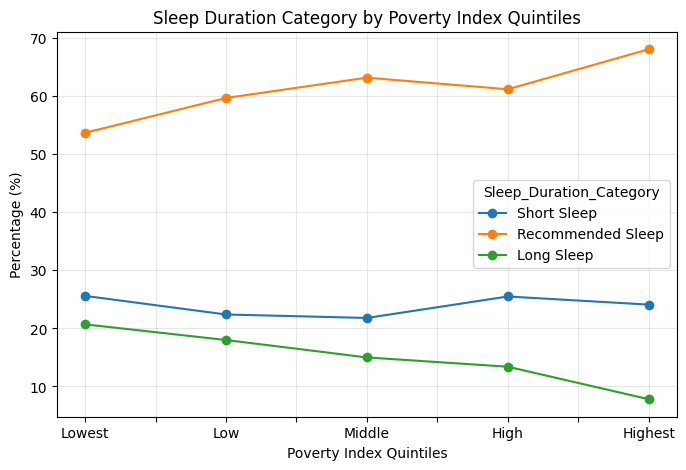

In [104]:
poverty_results["percentages"].plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Sleep Duration Category by Poverty Index Quintiles")
plt.xlabel("Poverty Index Quintiles")
plt.ylabel("Percentage (%)")
plt.grid(alpha=0.3)
plt.show()

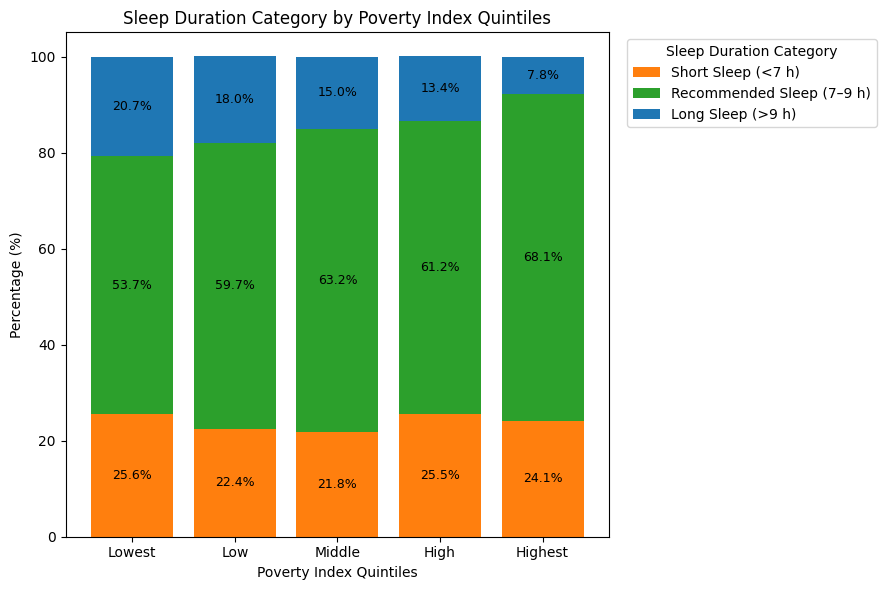

In [105]:
import matplotlib.pyplot as plt

colors = [
    "#ff7f0e",  # Short Sleep (orange)
    "#2ca02c",  # Recommended Sleep (green)
    "#1f77b4"   # Long Sleep (blue)
]

ax = (
    poverty_results["percentages"]
    .reindex(columns=["Short Sleep", "Recommended Sleep", "Long Sleep"])
    .plot(
        kind="bar",
        stacked=True,
        figsize=(9,6),
        width=0.8,
        color=colors
    )
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=9,
        label_type="center"
    )

plt.title("Sleep Duration Category by Poverty Index Quintiles")
plt.xlabel("Poverty Index Quintiles")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.legend(
    title="Sleep Duration Category",
    labels=[
        "Short Sleep (<7 h)",
        "Recommended Sleep (7–9 h)",
        "Long Sleep (>9 h)"
    ],
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [106]:
print(f"Chi-square: {poverty_results['chi2']:.2f}")
print(f"Degrees of freedom: {poverty_results['dof']}")
print(f"P-value: {poverty_results['p']:.4f}")
print(f"Cramer's V: {poverty_results['cramers_v']:.3f}")

Chi-square: 96.34
Degrees of freedom: 8
P-value: 0.0000
Cramer's V: 0.094


### Interpretation

The stacked bar chart shows that the distribution of sleep-duration categories varies according to participants' socioeconomic status. Those with a **lower Poverty Index**, i.e., with an economic situation closer to the poverty threshold, have the lowest proportion of recommended sleep (53.7%) and the highest proportion of prolonged sleep (20.7%).

As socioeconomic status improves (higher Poverty Index), the proportion of participants with **Recommended Sleep** tends to increase, reaching 68.1% in the group with the highest Poverty Index, although a slight decrease is observed in one of the intermediate groups.

Conversely, the proportion of **Long Sleep** decreases progressively from 20.7% to 7.8%. In contrast, **Short Sleep** shows small fluctuations across groups and does not display a clearly linear trend.

Overall, the results suggest that a better socioeconomic situation is associated with a more favorable distribution of sleep duration, mainly characterized by a higher proportion of recommended sleep and a lower proportion of prolonged sleep.

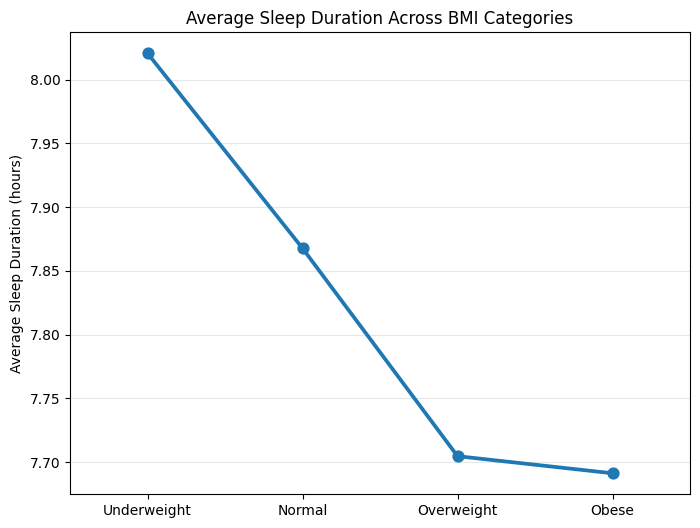

In [107]:
# For the presentation
order = ["Underweight", "Normal", "Overweight", "Obese"]

plt.figure(figsize=(8,6))

sns.pointplot(
    data=df,
    x="BMI_Category",
    y="Average_Sleep_Hours",
    order=order,
    errorbar=None,
    #errorbar=("ci", 95),
    capsize=0.15,
    markers="o",
    linestyles="-"
)

plt.title("Average Sleep Duration Across BMI Categories")
plt.xlabel("")
plt.ylabel("Average Sleep Duration (hours)")

plt.grid(axis="y", alpha=0.3)

plt.show()

# Final conclusions

Throughout this project, a complete data-analysis workflow was developed using Python and the **NHANES 2017–2018** dataset, covering integration and cleaning of multiple sources through exploratory and inferential analysis of the information.

The findings show that **sleep duration** is associated with various demographic characteristics, health indicators, and lifestyle-related factors. Although most detected associations exhibited a **small effect size**, they were statistically significant, suggesting that sleep is part of a complex, multifactorial phenomenon involving numerous biological, social, and behavioral determinants.

One of the main contributions of the project was the creation of derived variables, such as the **health profiles** and **lifestyle profiles**, which allowed multiple indicators to be synthesized into easily interpretable categories. This strategy facilitated the analysis and made it possible to identify patterns that would have been more difficult to observe by analyzing each variable in isolation.

From a methodological perspective, the project highlighted the importance of dedicating a substantial portion of the work to **data preparation**. Integration of different modules, handling of missing values, creation of new variables, and selection of clinical criteria based on international recommendations were essential steps to ensure the quality and consistency of subsequent analyses.

It is important to emphasize that, due to the **cross-sectional design** of NHANES, the results obtained allow identification of **associations**, but not establishment of causal relationships. Therefore, conclusions should be interpreted as evidence of patterns present in the studied population and not as demonstrations of cause–effect relationships.

Overall, this work enabled practical application of the main stages of a data-analysis project: acquisition, cleaning, transformation, exploration, visualization, statistical analysis, and interpretation of results. Beyond answering the research question posed, the project demonstrates the value of data analysis as a tool to generate useful knowledge from large population-based datasets.

---

## Final note

With the aim of keeping this notebook focused on the analytical and reproducible process, detailed interpretations of each result, discussion of the main insights, statistical justification, and the practical implications of the findings are developed in greater depth in the **final project presentation**, where each visualization and statistical test is contextualized and interpreted within the research framework.